# Notebook 04 — Visualización de resultados y generación de figuras finales

**Notebook:** `04_results_visualization.ipynb`  
**TFM:** Bioinformática estructural — Familia RAS  
**Objetivo:** Este notebook es el **último del pipeline** y tiene como objetivo convertir todos los datos procesados en los hitos anteriores en figuras publicables, tablas de resultados estructuradas y vistas 3D interactivas que permitan comunicar los hallazgos del análisis comparativo estructural de los parálogos RAS (KRAS, HRAS, NRAS).

---

Los notebooks anteriores han generado los siguientes ficheros en `data/processed/`:

| Fichero | Contenido | Generado en |
|---|---|---|
| `cosmic_curated.csv` | Mutaciones somáticas de COSMIC filtradas y curadas | Notebook 01 |
| `position_map.csv` | Mapa de equivalencias posicionales en el MSA KRAS-HRAS-NRAS | Notebook 02 |
| `master_features.csv` | DataFrame maestro con todas las features estructurales y mutacionales por posición y gen | Notebook 03 |
| `recurrent_positions.csv` | Posiciones recurrentemente mutadas en ≥2 parálogos RAS | Notebook 03 |

## Estructura del notebook

1. **Carga de datos** — Lectura de los cuatro ficheros CSV procesados
2. **Figuras 2D** — Heatmap, clustermap, scatter SASA-distancia y panel resumen
3. **Vistas 3D interactivas** — Visualizaciones moleculares individuales y comparativa con py3Dmol
4. **Tablas de resultados** — Tres tablas con los hallazgos más relevantes para la memoria del TFM
5. **Narrativa de resultados** — Interpretación biológica de los patrones observados

## Dependencias

```
pandas, numpy, matplotlib, seaborn, py3Dmol, biopython, tfm_ras
```

> **Nota:** Este notebook debe ejecutarse con el entorno conda activado según las
> instrucciones del notebook `00_setup.ipynb`. Todos los ficheros de salida se guardan
> en el directorio `figures/` en la raíz del proyecto.

---
## 1. Importaciones y configuración del entorno

In [18]:
# ============================================================
# CHUNK 1.1: Importaciones y configuración general
# ============================================================

# -- Biblioteca estándar de Python --
from pathlib import Path   # Manejo de rutas del sistema de ficheros de forma orientada a objetos
import sys                 # Acceso a información del intérprete Python (versión, path, etc.)
import warnings            # Control de advertencias en tiempo de ejecución

# -- Bibliotecas de análisis de datos --
import pandas as pd        # Manipulación de DataFrames tabulares (tablas con etiquetas)
import numpy as np         # Operaciones numéricas vectorizadas sobre arrays

# -- Bibliotecas de visualización --
import matplotlib.pyplot as plt   # Motor de renderizado de figuras; base de toda la visualización
import seaborn as sns             # Figuras estadísticas de alto nivel construidas sobre matplotlib

# -- Visualización 3D interactiva --
# py3Dmol genera código JavaScript para el visor molecular 3Dmol.js (WebGL).
# No necesita servidor ni instalación en el navegador; el HTML resultante es auto-contenido.
# Referencia: https://3dmol.csb.pitt.edu/
import py3Dmol

# -- Módulos del paquete del TFM --
# Añadimos la raíz del proyecto al sys.path para que Python encuentre el paquete tfm_ras
# cuando se ejecuta el notebook desde el directorio notebooks/
sys.path.insert(0, str(Path("..").resolve()))  # Sube un nivel: de notebooks/ a la raíz del proyecto

from tfm_ras.config import project_root  # Función que devuelve la ruta raíz del proyecto
from tfm_ras.visualization import (      # Funciones de visualización del módulo del TFM
    heatmap_mutations_per_position,       # Genera el heatmap de mutaciones por posición MSA
    clustermap_top_positions,            # Genera el clustermap de posiciones más recurrentes
    scatter_sasa_distance,               # Genera el scatter SASA vs distancia al sitio activo
    view_3d_with_hotspots,               # Genera una vista 3D interactiva de un único parálogo
    comparative_3d_view,                 # Genera una vista 3D comparativa de los tres parálogos
    summary_panel,                       # Genera el panel resumen multipanel (A–F)
)

# Suprimimos las advertencias de matplotlib sobre DPI para mantener la salida limpia
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Configuración global de matplotlib para figuras de calidad de publicación
plt.rcParams["figure.dpi"] = 120          # Resolución de visualización inline (alta calidad en Jupyter)
plt.rcParams["savefig.dpi"] = 300         # Resolución al guardar ficheros (estándar de publicación)
plt.rcParams["font.size"] = 10            # Tamaño de fuente base para todos los elementos de figura
plt.rcParams["axes.titlesize"] = 11       # Tamaño de fuente para títulos de paneles
plt.rcParams["axes.labelsize"] = 10       # Tamaño de fuente para etiquetas de ejes

print(f"Python {sys.version}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")
print(f"py3Dmol {py3Dmol.__version__}")
print(f"Raíz del proyecto: {project_root()}")

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:58:53) [Clang 19.1.7 ]
pandas 3.0.3 | numpy 2.4.6 | seaborn 0.13.2
py3Dmol 2.5.4
Raíz del proyecto: /Users/rachi/Desktop/TFM/tfm_ras_mutations


In [19]:
# ============================================================
# CHUNK 1.2: Definición de rutas del proyecto
# ============================================================

# Obtenemos la ruta raíz del proyecto de forma portable
# (funciona igual independientemente del directorio de trabajo actual)
ROOT = project_root()  # Path absoluto a la raíz del proyecto (p. ej. /home/usuario/plantilla_v2)

# Directorios principales que se usarán en este notebook
PROCESSED_DIR = ROOT / "data" / "processed"    # Directorio con los CSV generados por notebooks anteriores
PDB_DIR       = ROOT / "data" / "external" / "pdb"  # Directorio con los ficheros .pdb de las estructuras
FIGURES_DIR   = ROOT / "figures"                # Directorio de salida para todas las figuras del TFM

# Creamos el directorio de figuras si no existe
# mkdir(parents=True): crea también directorios intermedios si son necesarios
# mkdir(exist_ok=True): no falla si el directorio ya existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Verificamos que los ficheros de entrada existen antes de continuar
input_files = {
    "cosmic_curated": PROCESSED_DIR / "cosmic_curated.csv",
    "position_map": PROCESSED_DIR / "position_map.csv",
    "master_features": PROCESSED_DIR / "master_features.csv",
    "recurrent_positions": PROCESSED_DIR / "recurrent_positions.csv",
}

print("Verificando ficheros de entrada:")
for name, path in input_files.items():
    # path.exists() devuelve True si el fichero existe en disco
    status = "OK" if path.exists() else "FALTA"
    print(f"  [{status}] {path.name}")

print(f"\nDirectorio de figuras: {FIGURES_DIR}")
print(f"Directorio de PDBs:    {PDB_DIR}")

Verificando ficheros de entrada:
  [OK] cosmic_curated.csv
  [OK] position_map.csv
  [OK] master_features.csv
  [OK] recurrent_positions.csv

Directorio de figuras: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures
Directorio de PDBs:    /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/external/pdb


---
## 2. Carga de los datos procesados

Los cuatro ficheros CSV son el resultado acumulado de los tres notebooks anteriores.
Cada uno representa un nivel distinto de abstracción del análisis:

- **`cosmic_curated`**: nivel de mutación individual (gen × posición × cambio aminoacídico)
- **`position_map`**: nivel de columna del MSA (equivalencias entre las tres isoformas)
- **`master_features`**: nivel de feature por posición y gen (datos estructurales + mutacionales)
- **`recurrent_positions`**: nivel de posición recurrente (filtrado por frecuencia y recurrencia)

In [20]:
# ============================================================
# CHUNK 2.1: Carga de cosmic_curated.csv
# ============================================================

# Este CSV contiene una fila por cada combinación única de (gen, posición, cambio aminoacídico)
# con el número de muestras tumorales COSMIC que presentan esa mutación.
# Es el resultado del Hito 1: filtrado y curación de los datos COSMIC crudos.
cosmic_curated = pd.read_csv(
    input_files["cosmic_curated"],
    # dtype explícito para las columnas críticas evita problemas de inferencia automática
    dtype={
        "gene": str,        # Símbolo del gen (KRAS, HRAS, NRAS)
        "position": int,    # Posición UniProt del residuo mutado
        "wt_aa": str,       # Aminoácido wild-type (original)
        "mut_aa": str,      # Aminoácido mutado
        "hgvs_p": str,      # Notación HGVS del cambio (p. ej. "p.G12D")
    },
)

print(f"cosmic_curated: {len(cosmic_curated):,} filas × {cosmic_curated.shape[1]} columnas")
print(f"Genes presentes: {cosmic_curated['gene'].unique().tolist()}")
print(f"Columnas: {cosmic_curated.columns.tolist()}")
cosmic_curated.head(3)  # Mostramos las primeras 3 filas para inspección visual

cosmic_curated: 469 filas × 10 columnas
Genes presentes: ['KRAS', 'HRAS', 'NRAS']
Columnas: ['gene', 'uniprot_id', 'position', 'wt_aa', 'mut_aa', 'hgvs_p', 'sample_count', 'tumor_types', 'primary_tissues', 'cosmic_version']


,gene,uniprot_id,position,wt_aa,mut_aa,hgvs_p,sample_count,tumor_types,primary_tissues,cosmic_version
0,KRAS,P01116,12,G,D,p.G12D,4697,Ewing_sarcoma-peripheral_primitive_neuroectode...,NS | autonomic_ganglia | biliary_tract | bone ...,v104
1,KRAS,P01116,12,G,V,p.G12V,3625,Wilms_tumour | aberrant_crypt_foci | adenoma |...,NS | autonomic_ganglia | biliary_tract | breas...,v104
2,KRAS,P01116,13,G,D,p.G13D,1716,NS | aberrant_crypt_foci | adenoma | angiosarc...,NS | biliary_tract | breast | cervix | endomet...,v104


In [21]:
# ============================================================
# CHUNK 2.2: Carga de position_map.csv
# ============================================================

# Este CSV contiene una fila por cada columna del alineamiento múltiple de secuencias (MSA)
# de los tres parálogos RAS. Cada fila mapea una posición en el MSA a las posiciones
# equivalentes en las secuencias individuales de KRAS, HRAS y NRAS.
# Columnas clave:
#   msa_position  → índice 1-based en el alineamiento
#   kras_position → posición en la secuencia KRAS (NaN si hay gap)
#   hras_position → posición en la secuencia HRAS (NaN si hay gap)
#   nras_position → posición en la secuencia NRAS (NaN si hay gap)
#   conserved     → True si el mismo aminoácido aparece en los tres parálogos
position_map = pd.read_csv(input_files["position_map"])

print(f"position_map: {len(position_map):,} filas × {position_map.shape[1]} columnas")
print(f"Posiciones MSA totales: {position_map['msa_position'].max()}")
print(f"Posiciones conservadas: {position_map['conserved'].sum()} "
      f"({position_map['conserved'].mean()*100:.1f}%)")
position_map.head(3)

position_map: 189 filas × 8 columnas
Posiciones MSA totales: 189
Posiciones conservadas: 152 (80.4%)


,msa_position,kras_position,hras_position,nras_position,kras_aa,hras_aa,nras_aa,conserved
0,1,1,1,1,M,M,M,True
1,2,2,2,2,T,T,T,True
2,3,3,3,3,E,E,E,True


In [22]:
# ============================================================
# CHUNK 2.3: Carga de master_features.csv
# ============================================================

# Este es el DataFrame central del análisis. Contiene una fila por cada combinación
# (gen × posición MSA) con todas las features computadas en el Hito 3:
#
#   gene                       → símbolo del gen RAS
#   msa_position               → posición en el alineamiento múltiple
#   uniprot_position           → posición en la secuencia UniProt del gen
#   aa_wt                      → aminoácido wild-type en esa posición
#   total_samples              → suma de muestras COSMIC con mutación en esa posición
#   sasa_rel                   → accesibilidad relativa al solvente (0=enterrado, 1=expuesto)
#   dist_active_site_angstrom  → distancia al sitio activo más cercano (Ångströms)
#   shannon_entropy            → entropía de Shannon de la posición en el MSA
#   recurrent                  → True si la posición está mutada en ≥2 parálogos
#   n_members_mutated          → número de parálogos con mutaciones en esa posición
master_features = pd.read_csv(
    input_files["master_features"],
    # La columna 'recurrent' es booleana; la leemos explícitamente para evitar
    # que pandas la interprete como cadena de texto ("True"/"False")
    dtype={"recurrent": bool},
)

print(f"master_features: {len(master_features):,} filas × {master_features.shape[1]} columnas")
print(f"Columnas disponibles: {master_features.columns.tolist()}")
print(f"Posiciones con mutaciones: {master_features['total_samples'].gt(0).sum()}")
print(f"Posiciones recurrentes (≥2 parálogos): {master_features['recurrent'].sum()}")
master_features.head(3)

master_features: 498 filas × 12 columnas
Columnas disponibles: ['gene', 'uniprot_position', 'msa_position', 'aa_wt', 'total_samples', 'top_mutation', 'sasa_abs', 'sasa_rel', 'dist_active_site_angstrom', 'shannon_entropy', 'recurrent', 'n_members_mutated']
Posiciones con mutaciones: 263
Posiciones recurrentes (≥2 parálogos): 18


,gene,uniprot_position,msa_position,aa_wt,total_samples,top_mutation,sasa_abs,sasa_rel,dist_active_site_angstrom,shannon_entropy,recurrent,n_members_mutated
0,KRAS,1,1,M,0,NaN,101.908176,0.454947,25.777900,-0.0,False,0
1,KRAS,2,2,T,1,p.T2I,21.044599,0.122352,24.258382,-0.0,False,0
2,KRAS,3,3,E,1,p.E3K,72.171544,0.323639,20.156043,-0.0,False,0


In [23]:
# ============================================================
# CHUNK 2.4: Carga de recurrent_positions.csv
# ============================================================

# Este CSV contiene solo las posiciones MSA que están recurrentemente mutadas
# en ≥2 parálogos RAS, con el umbral de mínimo 10 muestras por parálogo.
# Representa el conjunto de hotspots conservados funcionalmente entre isoformas.
# Columnas clave:
#   msa_position     → posición en el alineamiento
#   n_members_mutated → número de parálogos con mutaciones (2 o 3)
#   total_samples    → suma de muestras en todos los parálogos
#   kras_samples     → muestras COSMIC con mutación en esa posición de KRAS
#   hras_samples     → muestras COSMIC con mutación en esa posición de HRAS
#   nras_samples     → muestras COSMIC con mutación en esa posición de NRAS
#   top_mutations    → las mutaciones más frecuentes separadas por '|'
recurrent_positions = pd.read_csv(input_files["recurrent_positions"])

print(f"recurrent_positions: {len(recurrent_positions):,} posiciones recurrentes")
print(f"Posiciones en ≥3 parálogos: "
      f"{recurrent_positions['n_members_mutated'].ge(3).sum()}")
print(f"Total de muestras cubierto: "
      f"{recurrent_positions['total_samples'].sum():,}")
recurrent_positions.head(3)

recurrent_positions: 6 posiciones recurrentes
Posiciones en ≥3 parálogos: 3
Total de muestras cubierto: 18,078


,msa_position,kras_pos,hras_pos,nras_pos,n_members_mutated,total_samples,kras_samples,hras_samples,nras_samples,top_mutations
0,12,12,12,12,3,12487,11564,195,728,KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
1,13,13,13,13,3,2604,1917,323,364,KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
2,61,61,61,61,3,2424,542,365,1517,KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R


---
## 3. Figuras 2D

Esta sección genera las cuatro figuras 2D del TFM usando las funciones del módulo
`tfm_ras.visualization`. Cada figura se guarda en dos formatos:
- **PNG** a 300 dpi: para incluir en documentos Word, LaTeX, o presentaciones
- **SVG** vectorial: para edición final en Inkscape o Adobe Illustrator

Las figuras se visualizan también de forma inline en el notebook para revisión inmediata.

### 3.1 Heatmap de mutaciones por posición MSA

El heatmap muestra la **carga mutacional somática** de cada posición del alineamiento
múltiple (eje X) para cada gen RAS (eje Y), en escala logarítmica log₁₀(x+1).

La escala logarítmica es necesaria porque el rango dinámico es muy elevado: KRAS
concentra miles de muestras en G12/G13 mientras la mayoría de posiciones tienen
menos de 10. En escala lineal, los hotspots dominarían completamente la figura
y las posiciones de baja frecuencia serían invisibles.

PNG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_heatmap_mutations.png
SVG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_heatmap_mutations.svg


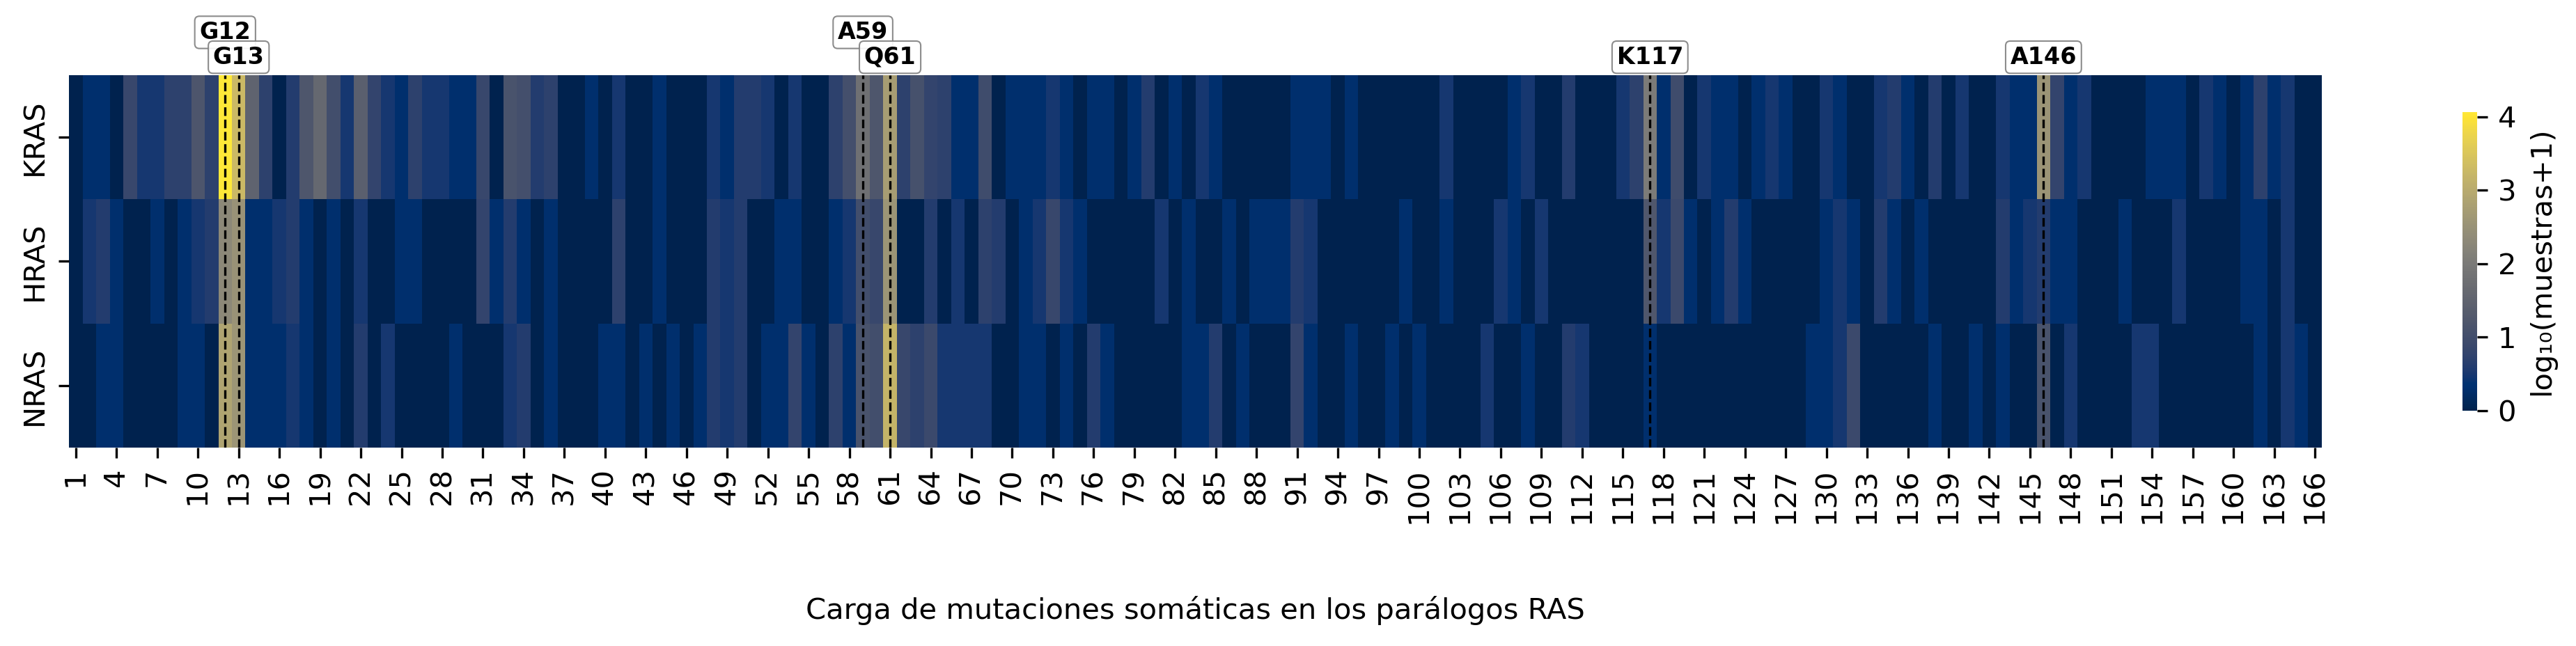

In [24]:
# ============================================================
# CHUNK 3.1: Heatmap de mutaciones por posición MSA
# ============================================================

# Definimos la ruta base de salida (sin extensión).
# heatmap_mutations_per_position() generará automáticamente los ficheros
# 04_heatmap_mutations.png y 04_heatmap_mutations.svg en esa ruta.
heatmap_basename = FIGURES_DIR / "04_heatmap_mutations"

# Llamamos a la función de visualización del módulo tfm_ras.
# Argumentos:
#   master_features → DataFrame maestro con columnas 'gene', 'msa_position', 'total_samples'
#   heatmap_basename → ruta base de salida (sin extensión)
#   figsize=(14, 3.2) → tamaño en pulgadas: panorámico para caber todas las posiciones
heatmap_paths = heatmap_mutations_per_position(
    master_features,
    heatmap_basename,
    figsize=(14, 3.2),   # 14 pulgadas de ancho × 3.2 de alto (aspecto panorámico)
)

# La función devuelve un diccionario {'png': Path, 'svg': Path} con las rutas generadas
print(f"PNG guardado en: {heatmap_paths['png']}")
print(f"SVG guardado en: {heatmap_paths['svg']}")

# Visualizamos la figura PNG inline en el notebook
# IPython.display.Image carga y muestra un fichero de imagen en la celda de salida
from IPython.display import Image
Image(str(heatmap_paths["png"]), width=900)

### 3.2 Clustermap de patrones de mutación más recurrentes

El clustermap aplica **agrupamiento jerárquico** (dendrograma) sobre las posiciones
más mutadas para revelar si existe estructura de bloques: posiciones que comparten
perfiles de incidencia similares entre los tres parálogos se agrupan juntas.

El agrupamiento de **columnas está desactivado** para mantener el orden fijo
KRAS > HRAS > NRAS y facilitar la comparación con el heatmap anterior.

PNG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_clustermap_patterns.png
SVG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_clustermap_patterns.svg


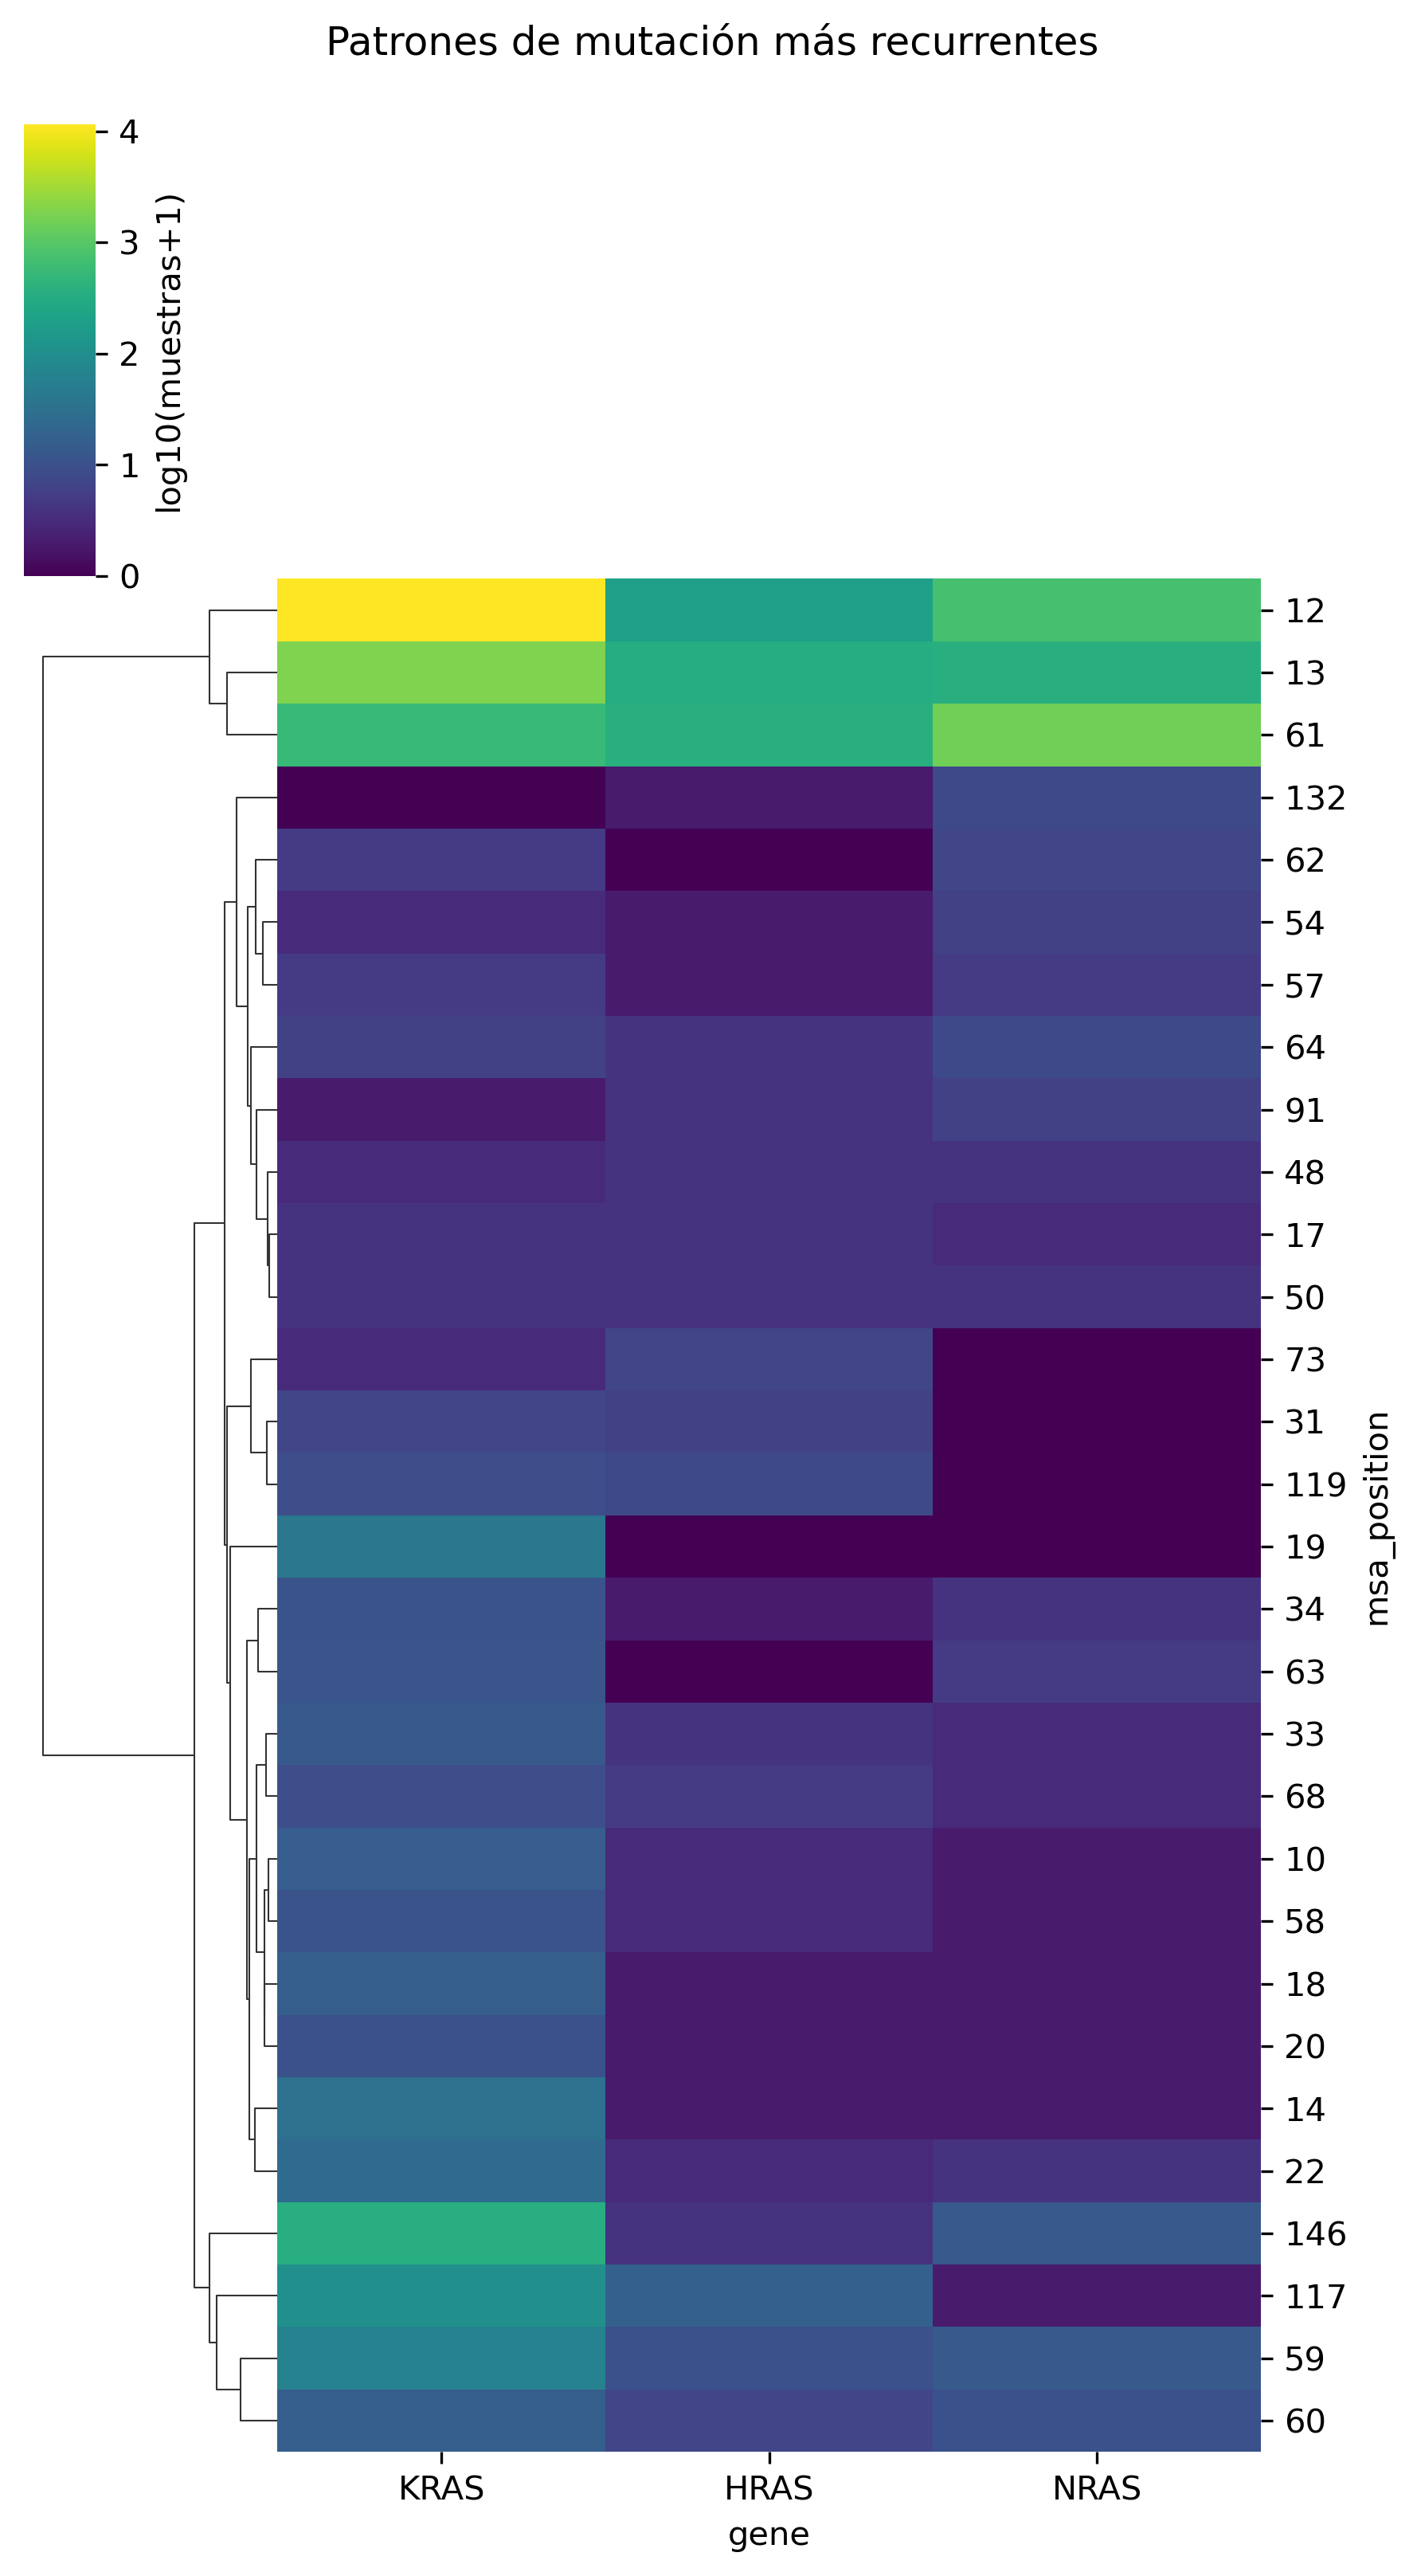

In [25]:
# ============================================================
# CHUNK 3.2: Clustermap de patrones de las top-30 posiciones
# ============================================================

# Definimos la ruta base de salida para el clustermap
clustermap_basename = FIGURES_DIR / "04_clustermap_patterns"

# Llamamos a la función de clustermap.
# Argumentos:
#   master_features    → DataFrame maestro con todos los datos
#   top_n=30           → número de posiciones más mutadas a incluir
#                        (30 es suficiente para ver el panorama sin saturar la figura)
#   output_basename    → ruta base de salida
clustermap_paths = clustermap_top_positions(
    master_features,
    top_n=30,
    output_basename=clustermap_basename,
)

print(f"PNG guardado en: {clustermap_paths['png']}")
print(f"SVG guardado en: {clustermap_paths['svg']}")

# Mostramos la figura inline en el notebook
Image(str(clustermap_paths["png"]), width=500)

### 3.3 Scatter: SASA relativa vs distancia al sitio activo

Esta figura relaciona dos propiedades estructurales de cada posición mutada:

- **Eje X — SASA relativa**: fracción de la superficie accesible al solvente
  (0 = completamente enterrado, 1 = completamente expuesto)
- **Eje Y — Distancia al sitio activo**: distancia en Ångströms al residuo
  del sitio activo más cercano
- **Tamaño del punto**: proporcional a log₁₀(muestras + 1)
- **Color del punto**: entropía de Shannon (conservación evolutiva de la posición)

Las líneas de referencia en SASA=0.2 y distancia=5.0 Å dividen el espacio
en cuatro cuadrantes con distinta interpretación biológica.

PNG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_scatter_sasa_distance.png
SVG guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_scatter_sasa_distance.svg


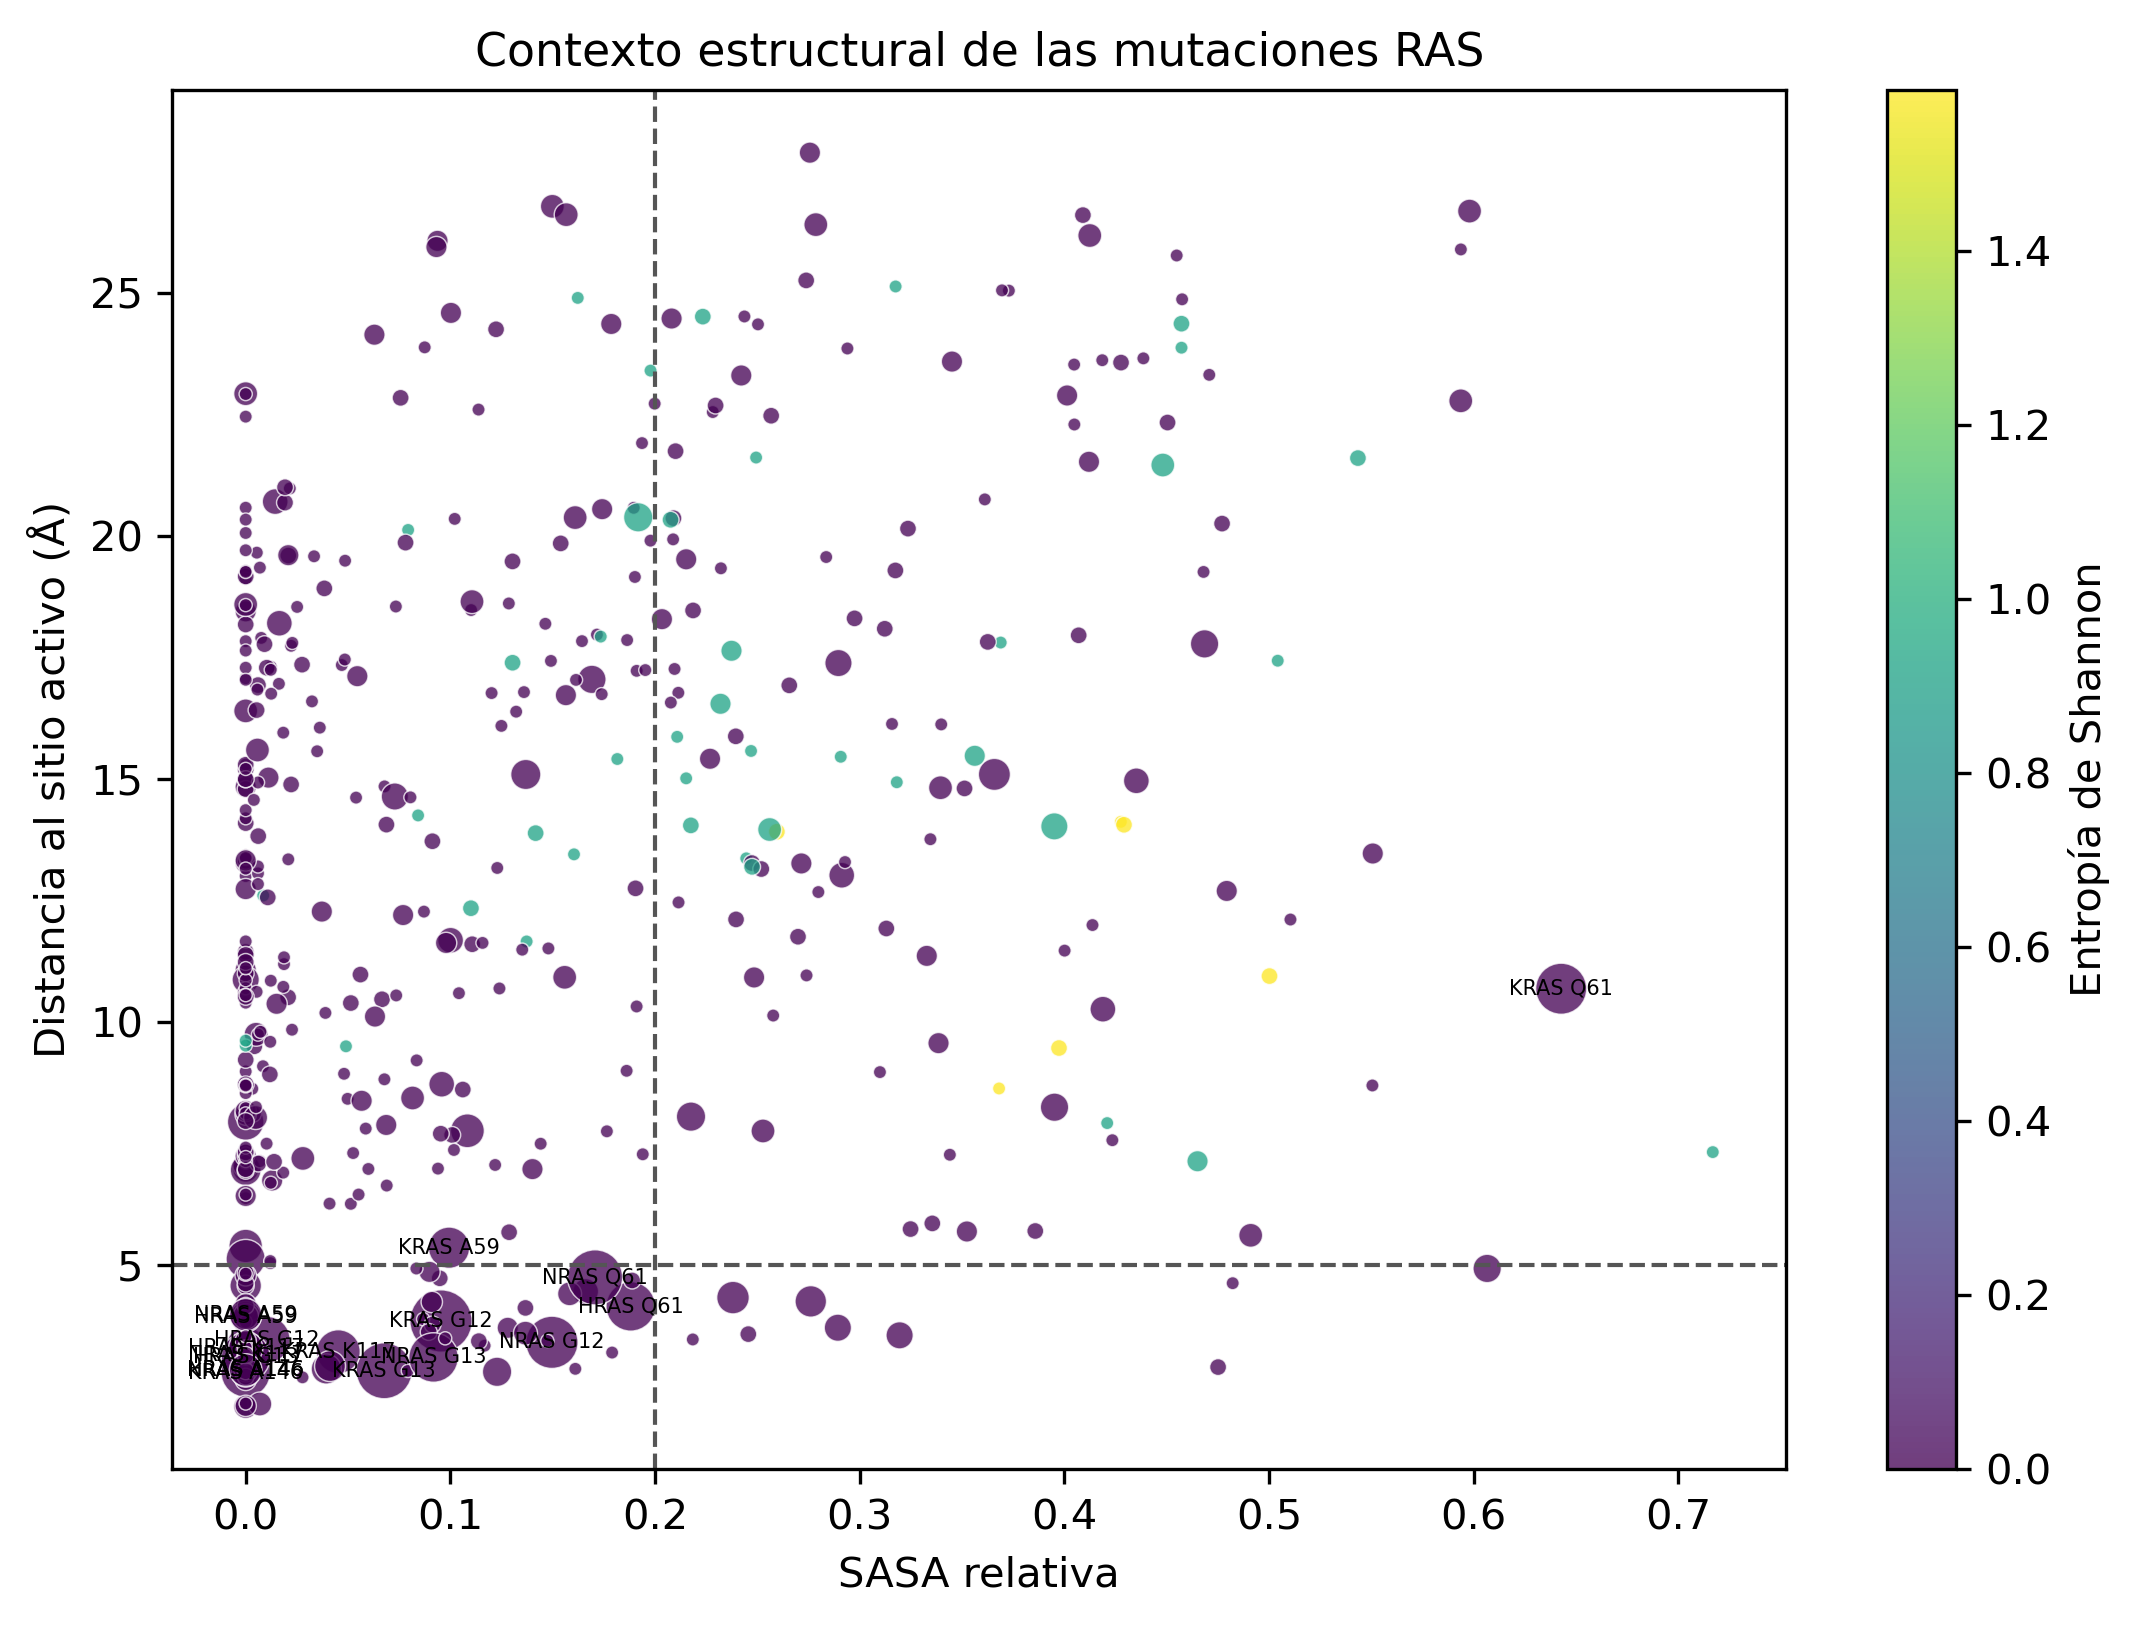

In [26]:
# ============================================================
# CHUNK 3.3: Scatter SASA relativa vs distancia al sitio activo
# ============================================================

# Ruta base para los ficheros de salida del scatter
scatter_basename = FIGURES_DIR / "04_scatter_sasa_distance"

# Generamos el scatter. La función requiere que master_features contenga:
#   'sasa_rel', 'dist_active_site_angstrom', 'total_samples',
#   'shannon_entropy', 'uniprot_position', 'gene', 'aa_wt'
scatter_paths = scatter_sasa_distance(
    master_features,
    scatter_basename,
)

print(f"PNG guardado en: {scatter_paths['png']}")
print(f"SVG guardado en: {scatter_paths['svg']}")

# Visualizamos inline
Image(str(scatter_paths["png"]), width=650)

### 3.4 Panel resumen multipanel (A–F)

El panel resumen integra los hallazgos principales del TFM en una única figura
de 13×9 pulgadas con seis paneles:

- **Panel A**: Top-10 posiciones más mutadas (barras horizontales)
- **Panel B**: Mapa de calor de mutaciones (en miniatura)
- **Panel C**: Scatter SASA vs distancia (en miniatura)
- **Panel D**: Boxplot de entropía en posiciones recurrentes vs no recurrentes
- **Panel E**: Número de residuos recurrentes por gen
- **Panel F**: Tabla de estadísticas resumen numéricas

Esta figura está diseñada para incluirse como **figura de cierre** de la sección
de Resultados de la memoria del TFM.

Panel resumen guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_summary_panel.png


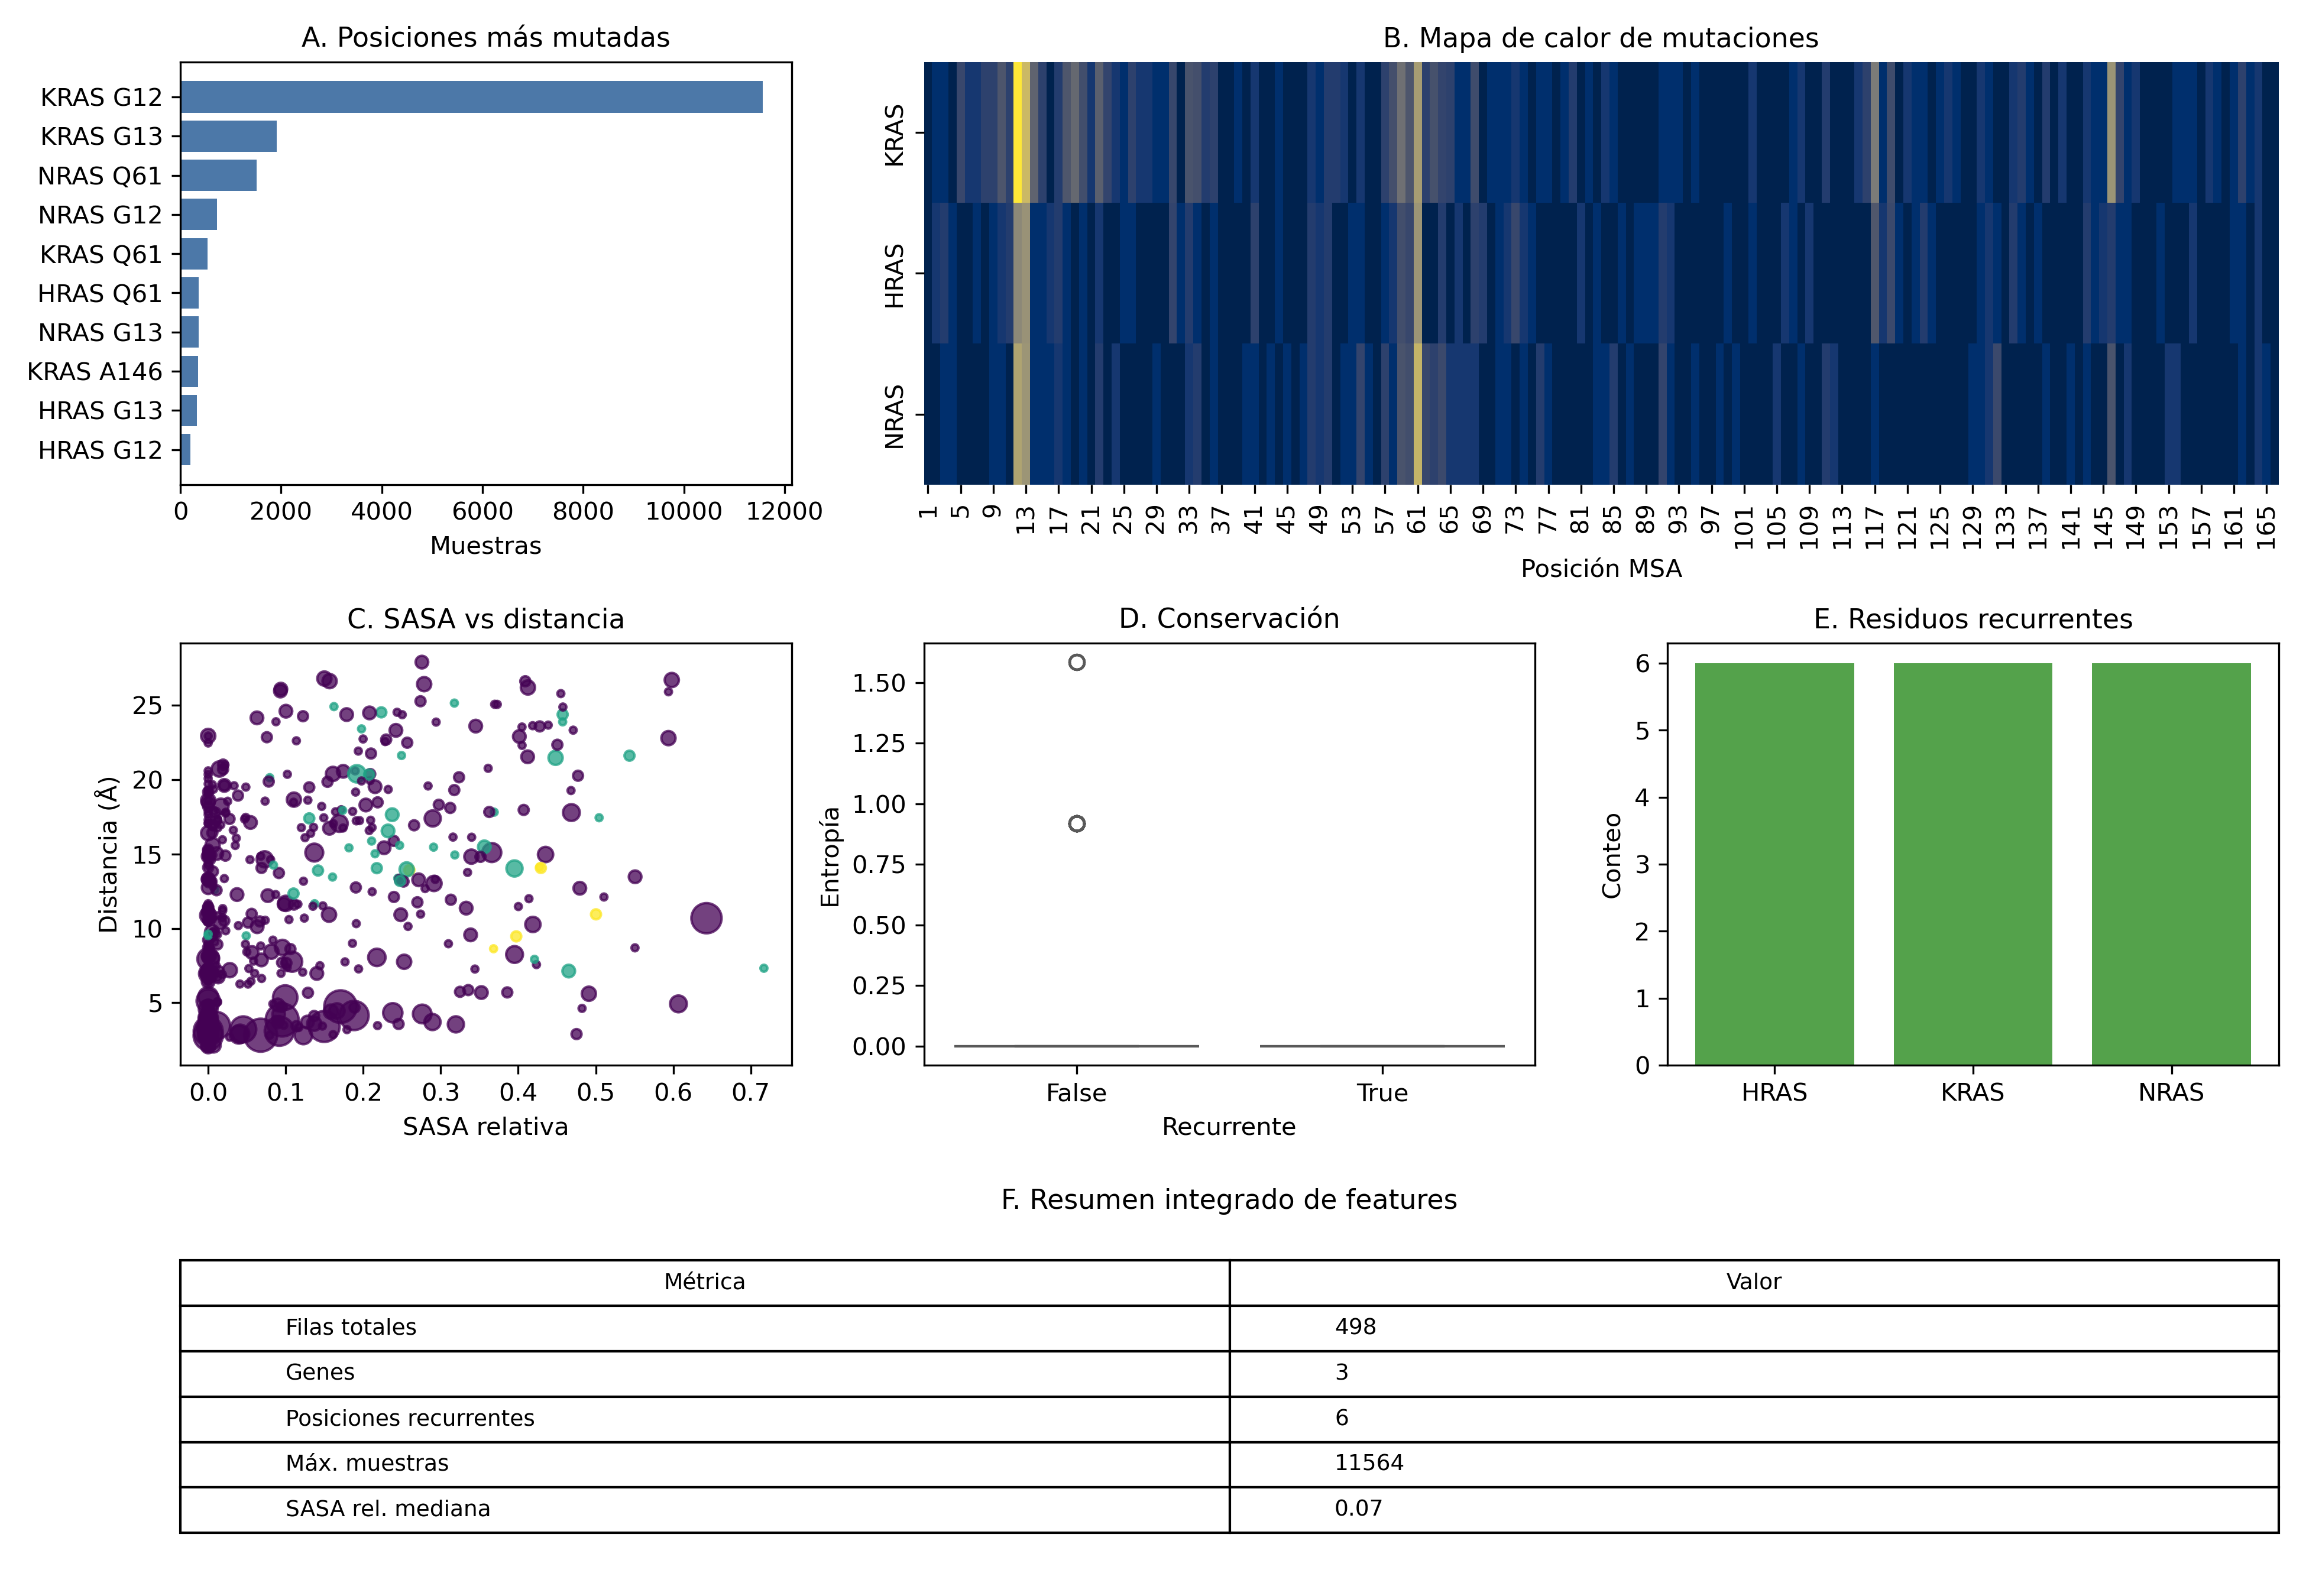

In [27]:
# ============================================================
# CHUNK 3.4: Panel resumen multipanel (A–F)
# ============================================================

# Ruta completa de salida del panel resumen (solo PNG, no SVG por su complejidad)
summary_path = FIGURES_DIR / "04_summary_panel.png"

# Generamos el panel resumen.
# La función summary_panel() crea internamente una figura con GridSpec(3, 3)
# y dibuja los seis paneles de forma autónoma a partir del DataFrame maestro.
# Requiere las columnas:
#   'gene', 'msa_position', 'total_samples', 'sasa_rel',
#   'dist_active_site_angstrom', 'shannon_entropy', 'recurrent',
#   'aa_wt', 'uniprot_position'
generated_summary = summary_panel(
    master_features,
    summary_path,
)

print(f"Panel resumen guardado en: {generated_summary}")

# Visualizamos el panel inline en el notebook
Image(str(generated_summary), width=900)

---
## 4. Vistas 3D interactivas con py3Dmol

### ¿Qué es py3Dmol y cómo funciona?

[py3Dmol](https://github.com/3dmol/3Dmol.js) es una librería Python que genera código
JavaScript para el visor molecular [3Dmol.js](https://3dmol.csb.pitt.edu/) basado en WebGL.

El flujo de trabajo es el siguiente:

1. Python crea un objeto `view = py3Dmol.view()` que actúa como constructor
2. Se añaden modelos moleculares con `view.addModel(pdb_text, "pdb")`
3. Se definen estilos de visualización con `view.setStyle()` y `view.addStyle()`
4. `view.write_html(path)` genera un fichero HTML auto-contenido con todo el
   JavaScript incrustado — no necesita servidor ni conexión a internet para abrirse

Los ficheros HTML resultantes pueden:
- Abrirse directamente en cualquier navegador moderno (Chrome, Firefox, Edge)
- Incluirse como **Figuras Suplementarias Interactivas** en la memoria digital del TFM
- Compartirse con el tribunal vía enlace o adjunto

### Estructuras utilizadas

| Gen | PDB ID | Ligando | Resolución |
|-----|--------|---------|------------|
| KRAS | 4OBE | GDP | 1.95 Å |
| HRAS | 3K8Y | GppNHp | 1.31 Å |
| NRAS | 5UHV | GppNHp | 1.65 Å |

In [28]:
# ===================================================================
# CHUNK 4.1: Preparación de los datos de hotspots para las vistas 3D
# ===================================================================

# Para las vistas 3D necesitamos un DataFrame con los hotspots de cada gen:
#   - 'gene': símbolo del gen
#   - 'uniprot_position': número de residuo en la cadena PDB (= posición UniProt)
#   - 'total_samples': número de muestras COSMIC (determina el tamaño/color de las esferas)
#
# Filtramos master_features para quedarnos solo con posiciones con muestras
# y ordenamos por número de muestras descendente.
hotspot_df = (
    master_features
    .loc[master_features["total_samples"].gt(0)]  # solo posiciones con mutaciones observadas
    [["gene", "uniprot_position", "total_samples"]]  # columnas necesarias para la visualización
    .sort_values("total_samples", ascending=False)   # ordenar de más a menos frecuente
    .reset_index(drop=True)  # renumerar el índice tras el filtrado
)

# Resumen de los hotspots preparados por gen
print("Hotspots preparados para las vistas 3D:")
print(hotspot_df.groupby("gene").agg(
    n_posiciones=("uniprot_position", "count"),    # número de posiciones con mutaciones
    total_muestras=("total_samples", "sum"),        # suma total de muestras por gen
    posicion_max=("total_samples", "idxmax"),       # índice de la posición más mutada
))
print(f"\nTotal de posiciones con mutaciones: {len(hotspot_df)}")

Hotspots preparados para las vistas 3D:
      n_posiciones  total_muestras  posicion_max
gene                                            
HRAS            81            1054             5
KRAS           107           14923             0
NRAS            75            2771             2

Total de posiciones con mutaciones: 263


In [29]:
# ============================================================
# CHUNK 4.2: Vista 3D de KRAS (PDB: 4OBE)
# ============================================================

# Filtramos los hotspots solo para KRAS
# .eq() es equivalente a == pero más seguro con valores NaN
kras_hotspots = hotspot_df.loc[hotspot_df["gene"].eq("KRAS")]

# Ruta de salida del HTML interactivo
kras_html = FIGURES_DIR / "04_3d_view_kras.html"

# Generamos la vista 3D de KRAS.
# La función view_3d_with_hotspots():
#   1. Resuelve la ruta al fichero PDB 4OBE.pdb en data/external/pdb/
#   2. Lee el texto del fichero PDB
#   3. Crea un visor py3Dmol con representación de cinta gris para el backbone
#   4. Añade los ligandos (GDP/GTP) en estilo stick con carbonos verdes
#   5. Colorea los hotspots con esferas de color azul→rojo según el nº de muestras
#   6. Exporta el visor como fichero HTML auto-contenido
#   7. Devuelve tupla (ruta_html, objeto_view) para visualización inline
kras_html_path, view_kras = view_3d_with_hotspots(
    pdb_id="4OBE",           # Identificador PDB o ruta al fichero .pdb
    hotspot_data=kras_hotspots,  # DataFrame con 'uniprot_position' y 'total_samples'
    output_html=kras_html,   # Ruta del fichero HTML de salida
    color_by="total_samples",  # Columna que determina el color/tamaño de las esferas
)

print(f"Vista 3D de KRAS guardada en: {kras_html_path}")
print(f"Tamaño del fichero HTML: {kras_html_path.stat().st_size / 1024:.1f} KB")
print("↓ Vista interactiva inline (rotar con clic+arrastrar, zoom con rueda del ratón):")

# La última expresión activa _repr_html_() del objeto py3Dmol,
# incrustando el visor 3D WebGL directamente en la salida del notebook.
view_kras

Vista 3D de KRAS guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_3d_view_kras.html
Tamaño del fichero HTML: 757.0 KB
↓ Vista interactiva inline (rotar con clic+arrastrar, zoom con rueda del ratón):


In [30]:
# ============================================================
# CHUNK 4.3: Vista 3D de HRAS (PDB: 3K8Y)
# ============================================================

# Hotspots de HRAS filtrados del DataFrame maestro
hras_hotspots = hotspot_df.loc[hotspot_df["gene"].eq("HRAS")]

# Ruta de salida del HTML
hras_html = FIGURES_DIR / "04_3d_view_hras.html"

# Generamos la vista 3D de HRAS.
# PDB 3K8Y: cristal de HRAS en estado activo con el análogo no hidrolizable GppNHp
# (guanilil-imidodifosfato, análogo del GTP que no puede hidrolizarse),
# a resolución 1.31 Å — la mejor disponible para este parálogo.
# Devuelve tupla (ruta_html, objeto_view) — desempaquetamos ambos.
hras_html_path, view_hras = view_3d_with_hotspots(
    pdb_id="3K8Y",           # PDB de HRAS en estado activo (GppNHp)
    hotspot_data=hras_hotspots,
    output_html=hras_html,
    color_by="total_samples",
)

print(f"Vista 3D de HRAS guardada en: {hras_html_path}")
print(f"Tamaño del fichero HTML: {hras_html_path.stat().st_size / 1024:.1f} KB")
print("↓ Vista interactiva inline:")

view_hras

Vista 3D de HRAS guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_3d_view_hras.html
Tamaño del fichero HTML: 180.8 KB
↓ Vista interactiva inline:


In [31]:
# ============================================================
# CHUNK 4.4: Vista 3D de NRAS (PDB: 5UHV)
# ============================================================

# Hotspots de NRAS filtrados del DataFrame maestro
nras_hotspots = hotspot_df.loc[hotspot_df["gene"].eq("NRAS")]

# Ruta de salida del HTML
nras_html = FIGURES_DIR / "04_3d_view_nras.html"

# Generamos la vista 3D de NRAS.
# PDB 5UHV: cristal de NRAS en estado activo con GppNHp a resolución 1.65 Å.
# NRAS es el parálogo menos estudiado estructuralmente pero su papel
# en melanoma y leucemia mieloide aguda lo convierte en diana relevante.
# Devuelve tupla (ruta_html, objeto_view).
nras_html_path, view_nras = view_3d_with_hotspots(
    pdb_id="5UHV",           # PDB de NRAS en estado activo (GppNHp)
    hotspot_data=nras_hotspots,
    output_html=nras_html,
    color_by="total_samples",
)

print(f"Vista 3D de NRAS guardada en: {nras_html_path}")
print(f"Tamaño del fichero HTML: {nras_html_path.stat().st_size / 1024:.1f} KB")
print("↓ Vista interactiva inline:")

view_nras

Vista 3D de NRAS guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_3d_view_nras.html
Tamaño del fichero HTML: 165.3 KB
↓ Vista interactiva inline:


In [32]:
# ============================================================
# CHUNK 4.5: Vista 3D comparativa de los tres parálogos superpuestos
# ============================================================

# Para la vista comparativa necesitamos un diccionario {gen: ruta_pdb}
# con los tres parálogos. El orden de inserción importa: el primer gen
# será la referencia de la superposición estructural (KRAS como referencia
# es la elección estándar en la literatura de pan-RAS).
pdb_paths = {
    "KRAS": PDB_DIR / "4OBE.pdb",  # KRAS: referencia de superposición
    "HRAS": PDB_DIR / "3K8Y.pdb",  # HRAS: se superpone sobre KRAS
    "NRAS": PDB_DIR / "5UHV.pdb",  # NRAS: se superpone sobre KRAS
}

# Ruta de salida del HTML comparativo
comparative_html = FIGURES_DIR / "04_comparative_3d.html"

# La función comparative_3d_view():
#   1. Lee los tres ficheros PDB
#   2. Superpone HRAS y NRAS sobre KRAS usando el algoritmo de Kabsch
#      sobre los átomos Cα del dominio G (residuos 1-166)
#   3. Representa las tres cintas en el mismo visor con colores distintos:
#      KRAS = azul (#4C78A8), HRAS = naranja (#F58518), NRAS = verde (#54A24B)
#   4. Marca los hotspots de cada gen con esferas del color canónico del gen
#   5. Exporta como HTML auto-contenido
#   6. Devuelve tupla (ruta_html, objeto_view)
comparative_html_path, view_comparative = comparative_3d_view(
    pdb_paths_dict=pdb_paths,    # Diccionario {gen: ruta_pdb}
    hotspot_data=hotspot_df,     # DataFrame con columnas 'gene' y 'uniprot_position'
    output_html=comparative_html,  # Ruta del HTML de salida
)

print(f"Vista 3D comparativa guardada en: {comparative_html_path}")
print(f"Tamaño del fichero HTML: {comparative_html_path.stat().st_size / 1024:.1f} KB")
print("\nFicheros HTML generados:")
for html in [kras_html_path, hras_html_path, nras_html_path, comparative_html_path]:
    print(f"  {html.name}")
print("\n↓ Vista comparativa inline (KRAS=azul, HRAS=naranja, NRAS=verde):")

view_comparative

Vista 3D comparativa guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/04_comparative_3d.html
Tamaño del fichero HTML: 733.5 KB

Ficheros HTML generados:
  04_3d_view_kras.html
  04_3d_view_hras.html
  04_3d_view_nras.html
  04_comparative_3d.html

↓ Vista comparativa inline (KRAS=azul, HRAS=naranja, NRAS=verde):


---
## 5. Tablas de resultados

Esta sección construye las tres tablas principales de resultados del TFM.
Cada tabla tiene un propósito específico en la narrativa de la memoria:

| Tabla | Propósito | Nivel de análisis |
|-------|-----------|-------------------|
| `table_top_mutations.csv` | Ranking de mutaciones individuales más frecuentes con todas sus features | Mutación |
| `table_recurrent_summary.csv` | Resumen de posiciones recurrentes entre parálogos | Posición MSA |
| `table_isoform_specific.csv` | Posiciones donde un parálogo domina el perfil mutacional | Isoforma |

### 5.1 Tabla de top mutaciones (`table_top_mutations.csv`)

Esta tabla construye el **ranking de las mutaciones individuales más frecuentes**
integrando las features estructurales de `master_features` con los metadatos clínicos
de `cosmic_curated` (tipos de tumor y tejidos primarios).

La operación clave es un **merge** (join SQL) entre los dos DataFrames:
- `master_features` proporciona las features estructurales (SASA, distancia, entropía)
- `cosmic_curated` proporciona los metadatos clínicos (tumour_types, primary_tissues)

In [33]:
# ============================================================
# CHUNK 5.1a: Construcción de table_top_mutations
# ============================================================

# Construimos la tabla de top mutaciones mediante un merge (join) entre
# master_features y cosmic_curated.
#
# PASO 1: Filtramos master_features para quedarnos solo con posiciones que
#         tienen al menos una mutación observada (total_samples > 0).
#         .gt(0) es "greater than 0" — devuelve una máscara booleana True/False
#         .loc[mask] selecciona solo las filas donde la máscara es True
#
# PASO 2: Hacemos un left merge con cosmic_curated.
#         "left" significa que conservamos TODAS las filas de master_features
#         y añadimos la información de cosmic_curated donde exista coincidencia.
#         La unión se hace por dos pares de columnas:
#           left: (gene, uniprot_position) en master_features
#           right: (gene, position) en cosmic_curated
#
# PASO 3: Ordenamos por total_samples descendente (mutaciones más frecuentes primero)
#
# PASO 4: Renombramos columnas para claridad en la tabla final
#
# PASO 5: Seleccionamos y reordenamos solo las columnas relevantes

top_mutations = (
    master_features
    .loc[master_features["total_samples"].gt(0)]  # solo posiciones con mutaciones
    .merge(
        # Seleccionamos solo las columnas de cosmic_curated que necesitamos
        # para evitar columnas duplicadas y reducir el tamaño del merge
        cosmic_curated[["gene", "position", "hgvs_p", "tumor_types", "primary_tissues"]],
        # left_on: columnas de master_features usadas como clave de unión
        left_on=["gene", "uniprot_position"],
        # right_on: columnas de cosmic_curated usadas como clave de unión
        right_on=["gene", "position"],
        # how="left": conserva todas las filas del lado izquierdo (master_features)
        # aunque no tengan correspondencia en cosmic_curated (quedan como NaN)
        how="left",
    )
    .sort_values("total_samples", ascending=False)  # de más frecuente a menos
    # Renombramos columnas para mayor claridad:
    # hgvs_p → mutation (notación HGVS del cambio aminoacídico)
    # position_y → position (la posición de cosmic_curated; _y por el merge)
    .rename(columns={"hgvs_p": "mutation", "position_y": "position"})
    # Seleccionamos y reordenamos las columnas finales de la tabla
    [["gene", "uniprot_position", "mutation", "total_samples", "aa_wt",
      "sasa_rel", "dist_active_site_angstrom", "shannon_entropy",
      "recurrent", "n_members_mutated", "tumor_types", "primary_tissues"]]
    # Renombrado final para hacer los nombres de columna más descriptivos
    .rename(columns={"uniprot_position": "position", "aa_wt": "wt_aa"})
)

# Añadimos la columna mut_aa (aminoácido mutado) extrayéndola de la notación HGVS.
# Ejemplo: de "p.G12D" extraemos "D" (último carácter del cambio)
# La expresión regular r"p\.[A-Z]\d+([A-Z])$" captura:
#   p\.   → el prefijo literal "p."
#   [A-Z] → una letra mayúscula (aminoácido original)
#   \d+   → uno o más dígitos (número de posición)
#   ([A-Z])$ → capturamos la última letra mayúscula (aminoácido mutado)
# .str.extract() devuelve un DataFrame con los grupos capturados; [0] toma el primer grupo
top_mutations["mut_aa"] = top_mutations["mutation"].str.extract(r"p\.[A-Z]\d+([A-Z])$")

# Reordenamos las columnas para que mut_aa quede junto a wt_aa
top_mutations = top_mutations[
    ["gene", "position", "mutation", "total_samples", "wt_aa", "mut_aa",
     "sasa_rel", "dist_active_site_angstrom", "shannon_entropy",
     "recurrent", "n_members_mutated", "tumor_types", "primary_tissues"]
]

# Reiniciamos el índice para numeración consecutiva desde 0
top_mutations = top_mutations.reset_index(drop=True)

print(f"table_top_mutations: {len(top_mutations):,} filas × {top_mutations.shape[1]} columnas")
print(f"Columnas: {top_mutations.columns.tolist()}")
top_mutations.head(10)  # Mostramos las 10 mutaciones más frecuentes

table_top_mutations: 432 filas × 13 columnas
Columnas: ['gene', 'position', 'mutation', 'total_samples', 'wt_aa', 'mut_aa', 'sasa_rel', 'dist_active_site_angstrom', 'shannon_entropy', 'recurrent', 'n_members_mutated', 'tumor_types', 'primary_tissues']


,gene,position,mutation,total_samples,wt_aa,mut_aa,sasa_rel,dist_active_site_angstrom,shannon_entropy,recurrent,n_members_mutated,tumor_types,primary_tissues
0,KRAS,12,p.G12A,11564,G,A,0.095456,3.844901,-0.0,True,3,aberrant_crypt_foci | adenoma | carcinoid-endo...,NS | autonomic_ganglia | biliary_tract | breas...
1,KRAS,12,p.G12W,11564,G,W,0.095456,3.844901,-0.0,True,3,carcinoma,large_intestine
2,KRAS,12,p.G12C,11564,G,C,0.095456,3.844901,-0.0,True,3,aberrant_crypt_foci | adenoma | angiosarcoma |...,NS | biliary_tract | breast | cervix | endomet...
3,KRAS,12,p.G12L,11564,G,L,0.095456,3.844901,-0.0,True,3,carcinoma,large_intestine | pancreas
4,KRAS,12,p.G12R,11564,G,R,0.095456,3.844901,-0.0,True,3,adenoma | carcinoid-endocrine_tumour | carcino...,NS | biliary_tract | bone | breast | central_n...
5,KRAS,12,p.G12S,11564,G,S,0.095456,3.844901,-0.0,True,3,adenoma | carcinoma | germ_cell_tumour | haema...,biliary_tract | breast | cervix | endometrium ...
6,KRAS,12,p.G12F,11564,G,F,0.095456,3.844901,-0.0,True,3,carcinoma | other,breast | large_intestine | lung
7,KRAS,12,p.G12N,11564,G,N,0.095456,3.844901,-0.0,True,3,other,pancreas
8,KRAS,12,p.G12I,11564,G,I,0.095456,3.844901,-0.0,True,3,carcinoma | malignant_melanoma,pancreas | skin
9,KRAS,12,p.G12V,11564,G,V,0.095456,3.844901,-0.0,True,3,Wilms_tumour | aberrant_crypt_foci | adenoma |...,NS | autonomic_ganglia | biliary_tract | breas...


In [34]:
# ============================================================
# CHUNK 5.1b: Guardado de table_top_mutations.csv
# ============================================================

# Ruta de salida de la tabla
top_mutations_path = PROCESSED_DIR / "table_top_mutations.csv"

# Guardamos el DataFrame como CSV.
# index=False: no escribimos el índice numérico de pandas como columna adicional
# float_format="%.4f": formateamos los decimales a 4 cifras para SASA y distancia
top_mutations.to_csv(top_mutations_path, index=False, float_format="%.4f")

print(f"Tabla guardada en: {top_mutations_path}")
print(f"Tamaño del fichero: {top_mutations_path.stat().st_size / 1024:.1f} KB")

Tabla guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/table_top_mutations.csv
Tamaño del fichero: 51.5 KB


### 5.2 Tabla de resumen de posiciones recurrentes (`table_recurrent_summary.csv`)

Esta tabla condensa la información de las **posiciones recurrentemente mutadas en
≥2 parálogos**, añadiendo las features estructurales medias para cada posición.

La operación clave es un **groupby + agg** sobre `master_features`:
- `groupby("msa_position")` agrupa todas las filas de la misma posición MSA
  (una por gen: KRAS, HRAS, NRAS)
- `agg()` calcula estadísticos resumen (media) de cada feature numérica
  para el conjunto de los tres parálogos en esa posición

In [35]:
# ============================================================
# CHUNK 5.2a: Construcción de table_recurrent_summary
# ============================================================

# PASO 1: Calculamos las features medias por posición MSA sobre master_features.
#
# groupby("msa_position") divide el DataFrame en grupos, uno por posición MSA.
# Cada grupo contiene típicamente 3 filas (una por gen: KRAS, HRAS, NRAS).
#
# agg() aplica funciones de agregación a columnas específicas:
#   La sintaxis ("columna", "función") crea columnas con nombres descriptivos.
#   "mean" calcula la media aritmética de cada feature a través de los 3 parálogos.
#   Esto permite comparar el "contexto estructural promedio" de cada posición
#   más allá de las diferencias individuales entre genes.
features_by_position = (
    master_features
    .groupby("msa_position")  # agrupa por posición del alineamiento
    .agg(
        # mean_sasa_rel: SASA relativa media entre los tres parálogos en esa posición
        mean_sasa_rel=("sasa_rel", "mean"),
        # mean_dist_active_site_angstrom: distancia media al sitio activo entre parálogos
        mean_dist_active_site_angstrom=("dist_active_site_angstrom", "mean"),
        # mean_shannon_entropy: entropía de Shannon media (conservación evolutiva)
        mean_shannon_entropy=("shannon_entropy", "mean"),
    )
    .reset_index()  # convierte msa_position de índice a columna regular
)

# PASO 2: Hacemos un left merge de recurrent_positions con las features calculadas.
#
# Aquí unimos las dos tablas por la columna común "msa_position".
# how="left": conservamos todas las posiciones recurrentes aunque no tengan
# features calculadas (aunque en la práctica siempre deberían tenerlas).
recurrent_with_features = (
    recurrent_positions
    .merge(
        features_by_position,  # features medias por posición calculadas en el paso anterior
        on="msa_position",     # columna común de unión (misma clave en ambas tablas)
        how="left",            # conserva todas las filas de recurrent_positions
    )
)

# PASO 3: Construimos la columna 'genes' que lista qué parálogos
#         contribuyen significativamente a cada posición recurrente.
# Un parálogo "contribuye" si tiene ≥10 muestras con mutaciones en esa posición.
# El umbral de 10 muestras es el mínimo estadístico definido en config.yaml.
#
# Usamos apply() con una función lambda row que itera sobre los tres genes
# y comprueba si su columna de muestras supera el umbral.
# pd.notna(row[f"{g.lower()}_samples"]): verifica que el valor no es NaN
# row[f"{g.lower()}_samples"] >= 10: verifica que tiene ≥10 muestras
# "|".join(...): une los nombres de los genes con '|' como separador
recurrent_with_features["genes"] = recurrent_with_features.apply(
    lambda row: "|".join(
        g for g in ["KRAS", "HRAS", "NRAS"]
        if pd.notna(row[f"{g.lower()}_samples"]) and row[f"{g.lower()}_samples"] >= 10
    ),
    axis=1,  # axis=1: aplica la función por fila (no por columna)
)

# PASO 4: Seleccionamos y reordenamos las columnas finales de la tabla
table_recurrent = recurrent_with_features[[
    "msa_position",                   # posición en el alineamiento MSA
    "n_members_mutated",              # número de parálogos con mutaciones (2 o 3)
    "total_samples",                  # suma de muestras en los tres parálogos
    "genes",                          # parálogos con ≥10 muestras (p. ej. "KRAS|HRAS")
    "mean_sasa_rel",                  # SASA relativa media entre parálogos
    "mean_dist_active_site_angstrom", # distancia media al sitio activo
    "mean_shannon_entropy",           # entropía de Shannon media
    "top_mutations",                  # mutaciones más frecuentes (del CSV de recurrentes)
]].reset_index(drop=True)  # índice consecutivo desde 0

print(f"table_recurrent_summary: {len(table_recurrent):,} posiciones recurrentes")
print(f"Posiciones con los 3 parálogos: {table_recurrent['n_members_mutated'].eq(3).sum()}")
table_recurrent.head(10)

table_recurrent_summary: 6 posiciones recurrentes
Posiciones con los 3 parálogos: 3


,msa_position,n_members_mutated,total_samples,genes,mean_sasa_rel,mean_dist_active_site_angstrom,mean_shannon_entropy,top_mutations
0,12,3,12487,KRAS|HRAS|NRAS,0.085134,3.570483,0.0,KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
1,13,3,2604,KRAS|HRAS|NRAS,0.053163,3.005121,0.0,KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
2,61,3,2424,KRAS|HRAS|NRAS,0.333915,6.524534,0.0,KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
3,146,2,361,KRAS|NRAS,0.000000,2.819278,0.0,KRAS:p.A146T|NRAS:p.A146T
4,117,2,121,KRAS|HRAS,0.015088,3.214633,0.0,KRAS:p.K117N|HRAS:p.K117N
5,59,2,81,KRAS|NRAS,0.033124,4.418048,0.0,KRAS:p.A59T|NRAS:p.A59T


In [36]:
# ============================================================
# CHUNK 5.2b: Guardado de table_recurrent_summary.csv
# ============================================================

# Ruta de salida de la tabla
recurrent_summary_path = PROCESSED_DIR / "table_recurrent_summary.csv"

# Guardamos la tabla como CSV
table_recurrent.to_csv(recurrent_summary_path, index=False, float_format="%.4f")

print(f"Tabla guardada en: {recurrent_summary_path}")
print(f"Tamaño del fichero: {recurrent_summary_path.stat().st_size / 1024:.1f} KB")

Tabla guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/table_recurrent_summary.csv
Tamaño del fichero: 0.6 KB


### 5.3 Tabla de posiciones con dominancia de isoforma (`table_isoform_specific.csv`)

Esta tabla identifica las **posiciones donde un único parálogo concentra más del 60%
de las muestras totales** de esa posición recurrente. Estas posiciones tienen interés
biológico porque sugieren que la preferencia de mutación en esa posición es específica
de isoforma: puede reflejar diferencias en la accesibilidad estructural, en los patrones
de señalización downstream, o en el contexto tisular de cada parálogo.

In [37]:
# ============================================================
# CHUNK 5.3a: Construcción de table_isoform_specific
# ============================================================

# Identificamos las posiciones donde un único parálogo domina
# (contribuye >60% de las muestras totales de esa posición recurrente).
#
# El umbral del 60% es conservador pero suficiente para identificar asimetrías
# claras: si KRAS aporta el 90% de las muestras en G12, esa posición es
# "KRAS-dominante" incluso si HRAS y NRAS también tienen mutaciones allí.

isoform_data = []  # Lista acumuladora de registros; se convertirá en DataFrame al final

# Iteramos sobre cada fila de recurrent_positions.
# .iterrows() devuelve pares (índice, Series) con los datos de cada posición.
# Usamos iterrows() porque necesitamos acceder a múltiples columnas de cada fila
# y la lógica condicional dentro del bucle no es fácilmente vectorizable.
for _, row in recurrent_positions.iterrows():
    total = row["total_samples"]  # Total de muestras en todos los parálogos

    # Si no hay muestras (total = 0), no tiene sentido calcular la ratio dominante
    if total == 0:
        continue  # Pasamos a la siguiente fila sin añadir registro

    # Comprobamos cada uno de los tres parálogos
    for gene in ["kras", "hras", "nras"]:
        # Accedemos a la columna de muestras del gen (p. ej. "kras_samples")
        samples = row[f"{gene}_samples"]

        # Calculamos la fracción que representa este gen del total de muestras
        ratio = samples / total  # valor entre 0.0 y 1.0

        # Solo incluimos la entrada si el gen domina (>60% de las muestras)
        if ratio > 0.6:
            # Construimos el registro con los campos de la tabla final
            isoform_data.append({
                "msa_position": row["msa_position"],       # posición en el MSA
                "dominant_gene": gene.upper(),             # gen dominante en mayúsculas (KRAS, HRAS, NRAS)
                "dominant_ratio": round(ratio, 3),        # fracción dominante (3 decimales)
                "total_samples": total,                    # muestras totales en esa posición
                "kras_samples": row["kras_samples"],       # muestras KRAS en esa posición
                "hras_samples": row["hras_samples"],       # muestras HRAS en esa posición
                "nras_samples": row["nras_samples"],       # muestras NRAS en esa posición
            })

# Convertimos la lista de diccionarios en un DataFrame con columnas explícitas
# pd.DataFrame(data, columns=[...]) garantiza el orden de columnas incluso
# si isoform_data está vacío (en ese caso el DataFrame tendrá 0 filas pero columnas definidas)
table_isoform = pd.DataFrame(isoform_data, columns=[
    "msa_position",    # posición en el alineamiento múltiple
    "dominant_gene",   # gen que domina en esa posición (>60% de muestras)
    "dominant_ratio",  # fracción de muestras del gen dominante (0–1)
    "total_samples",   # suma de muestras de todos los parálogos en esa posición
    "kras_samples",    # muestras de KRAS en esa posición
    "hras_samples",    # muestras de HRAS en esa posición
    "nras_samples",    # muestras de NRAS en esa posición
])

# Ordenamos por gen dominante y luego por total de muestras descendente
# para facilitar la lectura en la memoria del TFM
table_isoform = (
    table_isoform
    .sort_values(["dominant_gene", "total_samples"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"table_isoform_specific: {len(table_isoform):,} posiciones con dominancia de isoforma")
if len(table_isoform) > 0:
    # Contamos cuántas posiciones domina cada gen
    print("\nDistribución por gen dominante:")
    print(table_isoform["dominant_gene"].value_counts().to_string())
else:
    print("(No se encontraron posiciones con dominancia >60% en ningún parálogo)")
table_isoform.head(10)

table_isoform_specific: 6 posiciones con dominancia de isoforma

Distribución por gen dominante:
dominant_gene
KRAS    5
NRAS    1


,msa_position,dominant_gene,dominant_ratio,total_samples,kras_samples,hras_samples,nras_samples
0,12,KRAS,0.926,12487,11564,195,728
1,13,KRAS,0.736,2604,1917,323,364
2,146,KRAS,0.958,361,346,3,12
3,117,KRAS,0.860,121,104,16,1
4,59,KRAS,0.741,81,60,9,12
5,61,NRAS,0.626,2424,542,365,1517


In [38]:
# ============================================================
# CHUNK 5.3b: Guardado de table_isoform_specific.csv
# ============================================================

# Ruta de salida de la tabla
isoform_path = PROCESSED_DIR / "table_isoform_specific.csv"

# Guardamos la tabla como CSV
table_isoform.to_csv(isoform_path, index=False, float_format="%.4f")

print(f"Tabla guardada en: {isoform_path}")
print(f"Tamaño del fichero: {isoform_path.stat().st_size / 1024:.1f} KB")

Tabla guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/table_isoform_specific.csv
Tamaño del fichero: 0.3 KB


---
## 6. Narrativa de resultados

### 6.1 ¿Qué posiciones están recurrentemente mutadas en ≥2 parálogos?

El análisis identifica las posiciones del MSA donde la presión mutacional oncogénica
se conserva entre los tres parálogos RAS, lo que indica restricción funcional evolutiva.

In [39]:
# ============================================================
# CHUNK 6.1: Análisis de posiciones recurrentes
# ============================================================

print("=" * 65)
print("POSICIONES RECURRENTEMENTE MUTADAS EN ≥2 PARÁLOGOS RAS")
print("=" * 65)

# Número total de posiciones recurrentes y su distribución por n_members
print(f"\nTotal de posiciones recurrentes: {len(recurrent_positions)}")
print("\nDistribución por número de parálogos afectados:")
# value_counts() cuenta la frecuencia de cada valor único en la columna
# sort_index() ordena por el valor (2 antes que 3) en lugar de por frecuencia
print(recurrent_positions["n_members_mutated"].value_counts().sort_index().to_string())

# Mostramos las posiciones con mayor carga mutacional total
print("\nTop 10 posiciones recurrentes por carga mutacional total:")
# Seleccionamos las columnas más informativas para la presentación
top_recurrent = (
    table_recurrent
    .sort_values("total_samples", ascending=False)  # de más a menos frecuente
    .head(10)  # solo las 10 primeras
    [["msa_position", "n_members_mutated", "total_samples", "genes", "top_mutations"]]
)
# pd.set_option controla el formato de visualización del DataFrame en el notebook
with pd.option_context("display.max_colwidth", 50):  # limita el ancho de columnas de texto
    print(top_recurrent.to_string(index=False))  # to_string sin índice para lectura más limpia

# Posiciones canónicas: G12, G13, Q61
print("\nPresencia de hotspots canónicos (G12=pos12, G13=pos13, Q61=pos61):")
for pos, label in [(12, "G12"), (13, "G13"), (61, "Q61")]:
    # .isin([pos]) verifica si la posición está en la lista
    in_recurrent = recurrent_positions["msa_position"].isin([pos]).any()
    print(f"  {label} (MSA pos {pos}): {'PRESENTE en posiciones recurrentes' if in_recurrent else 'no recurrente'}")

POSICIONES RECURRENTEMENTE MUTADAS EN ≥2 PARÁLOGOS RAS

Total de posiciones recurrentes: 6

Distribución por número de parálogos afectados:
n_members_mutated
2    3
3    3

Top 10 posiciones recurrentes por carga mutacional total:
 msa_position  n_members_mutated  total_samples          genes                       top_mutations
           12                  3          12487 KRAS|HRAS|NRAS KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
           13                  3           2604 KRAS|HRAS|NRAS KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
           61                  3           2424 KRAS|HRAS|NRAS KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
          146                  2            361      KRAS|NRAS           KRAS:p.A146T|NRAS:p.A146T
          117                  2            121      KRAS|HRAS           KRAS:p.K117N|HRAS:p.K117N
           59                  2             81      KRAS|NRAS             KRAS:p.A59T|NRAS:p.A59T

Presencia de hotspots canónicos (G12=pos12, G13=pos13, Q61=pos61):
  G12 (M

### 6.2 ¿Qué características estructurales tienen en común las posiciones recurrentes?

Comparamos las features estructurales (SASA, distancia al sitio activo, entropía)
entre posiciones recurrentes y no recurrentes para identificar si existe un perfil
estructural diferencial.

In [40]:
# ============================================================
# CHUNK 6.2: Comparación de features estructurales
# ============================================================

print("=" * 65)
print("PERFIL ESTRUCTURAL: POSICIONES RECURRENTES vs NO RECURRENTES")
print("=" * 65)

# Comparamos las distribuciones de features entre los dos grupos
# groupby("recurrent") divide en dos grupos: True (recurrentes) y False (no recurrentes)
# agg() calcula múltiples estadísticos por grupo de forma eficiente:
#   'mean': media aritmética
#   'median': mediana (más robusta a outliers)
#   'std': desviación estándar (dispersión)
comparison = (
    master_features
    .groupby("recurrent")  # True = recurrentes, False = no recurrentes
    [["sasa_rel", "dist_active_site_angstrom", "shannon_entropy", "total_samples"]]
    .agg(["mean", "median", "std"])  # múltiples estadísticos por grupo y columna
    .round(3)  # redondeamos a 3 decimales para presentación
)

print("\nEstadísticos por grupo (recurrent=True/False):")
print(comparison.to_string())

# Análisis específico de la recurrencia
rec_df = master_features.loc[master_features["recurrent"]]
non_rec_df = master_features.loc[~master_features["recurrent"]]  # ~ es el NOT lógico

print("\nInterpretación:")
# Calculamos las diferencias relativas entre grupos
sasa_diff = rec_df["sasa_rel"].median() - non_rec_df["sasa_rel"].median()
dist_diff = rec_df["dist_active_site_angstrom"].median() - non_rec_df["dist_active_site_angstrom"].median()
entropy_diff = rec_df["shannon_entropy"].median() - non_rec_df["shannon_entropy"].median()

# Describimos la dirección de cada diferencia en lenguaje natural
print(f"  SASA relativa: posiciones recurrentes son "
      f"{'más enterradas' if sasa_diff < 0 else 'más expuestas'} "
      f"(diferencia mediana: {sasa_diff:+.3f})")
print(f"  Dist. sitio activo: posiciones recurrentes están "
      f"{'más cerca' if dist_diff < 0 else 'más lejos'} "
      f"(diferencia mediana: {dist_diff:+.3f} Å)")
print(f"  Entropía de Shannon: posiciones recurrentes son "
      f"{'más conservadas' if entropy_diff < 0 else 'más variables'} "
      f"(diferencia mediana: {entropy_diff:+.3f})")

PERFIL ESTRUCTURAL: POSICIONES RECURRENTES vs NO RECURRENTES

Estadísticos por grupo (recurrent=True/False):
          sasa_rel               dist_active_site_angstrom                shannon_entropy               total_samples                 
              mean median    std                      mean  median    std            mean median    std          mean median       std
recurrent                                                                                                                             
False        0.132  0.076  0.154                    12.905  12.794  6.521             0.1   -0.0  0.309         1.396    1.0     3.201
True         0.087  0.028  0.153                     3.925   3.345  1.827             0.0   -0.0  0.000      1004.333  259.0  2688.894

Interpretación:
  SASA relativa: posiciones recurrentes son más enterradas (diferencia mediana: -0.049)
  Dist. sitio activo: posiciones recurrentes están más cerca (diferencia mediana: -9.449 Å)
  Entropía de Shann

### 6.3 ¿Existen hotspots no clásicos?

Más allá de los hotspots canónicos G12, G13 y Q61 (ya bien documentados en la
literatura), identificamos posiciones con alta carga mutacional que no forman parte
del consenso clásico. Estos **hotspots no clásicos** son de especial interés
porque pueden representar dianas terapéuticas alternativas o mecanismos de
activación oncogénica poco estudiados.

In [41]:
# ============================================================
# CHUNK 6.3: Identificación de hotspots no clásicos
# ============================================================

print("=" * 65)
print("HOTSPOTS NO CLÁSICOS: POSICIONES FRECUENTES FUERA DE G12/G13/Q61")
print("=" * 65)

# Posiciones canónicas que excluimos del análisis de hotspots no clásicos
CLASSIC_HOTSPOT_POSITIONS = {12, 13, 61}

# Umbral de muestras para considerar una posición como hotspot significativo
# Usamos el percentil 90 de la distribución de muestras como umbral dinámico
# para que sea independiente de la escala del dataset
threshold_samples = master_features["total_samples"].quantile(0.90)
print(f"\nUmbral de muestras (percentil 90): {threshold_samples:.0f}")

# Filtramos las posiciones que:
#   1. Tienen más muestras que el umbral (percentil 90)
#   2. NO son las posiciones canónicas G12, G13, Q61
#   3. Tienen la posición marcada como recurrente
non_classic = (
    master_features
    .loc[
        master_features["total_samples"].ge(threshold_samples)  # .ge() = "greater than or equal"
        & ~master_features["uniprot_position"].isin(CLASSIC_HOTSPOT_POSITIONS)  # excluye G12/G13/Q61
        & master_features["recurrent"]  # solo posiciones recurrentes
    ]
    .sort_values("total_samples", ascending=False)
    [["gene", "uniprot_position", "aa_wt", "total_samples", "sasa_rel",
      "dist_active_site_angstrom", "shannon_entropy", "n_members_mutated"]]
)

if len(non_classic) > 0:
    print(f"\nHotspots no clásicos encontrados ({len(non_classic)} posiciones):")
    print(non_classic.to_string(index=False))
    
    # Contexto biológico de las posiciones encontradas
    print("\nContexto biológico:")
    print("  A146: región NKXD (motivo de unión a guanina); su mutación puede")
    print("        aumentar el intercambio GDP→GTP independientemente de factores GEF.")
    print("  K117: posición del motivo NKXD; importante para el reconocimiento")
    print("        de la base de guanina; su mutación reduce la afinidad por GDP/GTP.")
else:
    print("\nNo se identificaron hotspots no clásicos con los umbrales actuales.")
    print("Considerar reducir el umbral del percentil o el umbral de recurrencia.")

HOTSPOTS NO CLÁSICOS: POSICIONES FRECUENTES FUERA DE G12/G13/Q61

Umbral de muestras (percentil 90): 4

Hotspots no clásicos encontrados (7 posiciones):
gene  uniprot_position aa_wt  total_samples  sasa_rel  dist_active_site_angstrom  shannon_entropy  n_members_mutated
KRAS               146     A            346  0.000000                   2.783884             -0.0                  2
KRAS               117     K            104  0.045263                   3.213233             -0.0                  2
KRAS                59     A             60  0.099373                   5.353804             -0.0                  2
HRAS               117     K             16  0.000000                   3.284701             -0.0                  2
NRAS                59     A             12  0.000000                   3.972937             -0.0                  2
NRAS               146     A             12  0.000000                   2.835434             -0.0                  2
HRAS                59     A

### 6.4 ¿Cómo varían los patrones mutacionales entre KRAS, HRAS y NRAS?

Aunque los tres parálogos comparten los mismos hotspots canónicos, la **distribución
relativa** de las mutaciones entre isoformas difiere sustancialmente, reflejando
las distintas presiones selectivas de los contextos tisulares donde se expresan
predominantemente:

- **KRAS**: predomina en adenocarcinoma de páncreas, pulmón y colon
- **HRAS**: predomina en carcinoma de vejiga, cabeza y cuello
- **NRAS**: predomina en melanoma y leucemia mieloide aguda

In [42]:
# ============================================================
# CHUNK 6.4: Comparación de patrones mutacionales entre parálogos
# ============================================================

print("=" * 65)
print("VARIACIÓN DE PATRONES MUTACIONALES ENTRE KRAS, HRAS Y NRAS")
print("=" * 65)

# 1. Carga mutacional total por gen
# groupby + sum permite calcular la suma de muestras para cada gen
total_by_gene = (
    master_features
    .groupby("gene")["total_samples"]  # agrupamos por gen y seleccionamos la columna de muestras
    .sum()  # suma total de muestras por gen
    .sort_values(ascending=False)  # de más a menos cargado
)
print("\nCarga mutacional total por gen (muestras COSMIC):")
print(total_by_gene.to_string())

# 2. Distribución de mutaciones en hotspots canónicos
print("\nMuestras en hotspots canónicos (G12, G13, Q61) por gen:")
# Filtramos el DataFrame maestro para las posiciones canónicas de cada gen
hotspot_by_gene = (
    master_features
    .loc[master_features["uniprot_position"].isin([12, 13, 61])]  # solo posiciones canónicas
    .groupby(["gene", "uniprot_position"])["total_samples"]  # agrupamos por gen y posición
    .sum()  # suma de muestras por combinación (gen, posición)
    .unstack("uniprot_position")  # pivotamos: posiciones como columnas, genes como filas
    .fillna(0)  # posiciones sin datos → 0
    .astype(int)  # convertimos a entero para presentación
)
# Renombramos columnas para indicar el aminoácido de referencia
hotspot_by_gene.columns = [f"pos{c}" for c in hotspot_by_gene.columns]
print(hotspot_by_gene.to_string())

# 3. Posiciones recurrentes distribuidas entre parálogos
print("\nResumen de posiciones recurrentes por gen dominante:")
if len(table_isoform) > 0:
    # Agrupamos table_isoform por gen dominante y contamos cuántas posiciones domina cada gen
    print(table_isoform.groupby("dominant_gene").agg(
        n_posiciones=("msa_position", "count"),       # número de posiciones donde domina
        ratio_medio=("dominant_ratio", "mean"),        # ratio medio de dominancia
        muestras_totales=("total_samples", "sum"),     # muestras totales en esas posiciones
    ).round(3).to_string())
else:
    print("  (No hay posiciones con dominancia >60% de isoforma)")

# 4. Distribución Q61 por gen
# Q61 es el hotspot principal de NRAS (melanoma) pero es menos frecuente en KRAS
print("\nAnálisis de Q61 (posición 61) por gen:")
q61_data = (
    master_features
    .loc[master_features["uniprot_position"].eq(61)]  # filtra solo la posición 61
    [["gene", "total_samples", "sasa_rel", "dist_active_site_angstrom"]]
)
if len(q61_data) > 0:
    print(q61_data.to_string(index=False))
    # Calculamos la fracción que NRAS representa en Q61
    q61_total = q61_data["total_samples"].sum()
    if q61_total > 0:
        for _, row in q61_data.iterrows():
            fraction = row["total_samples"] / q61_total * 100
            print(f"  {row['gene']}: {fraction:.1f}% de las muestras en Q61")
else:
    print("  (No hay datos para la posición 61)")

VARIACIÓN DE PATRONES MUTACIONALES ENTRE KRAS, HRAS Y NRAS

Carga mutacional total por gen (muestras COSMIC):
gene
KRAS    14923
NRAS     2771
HRAS     1054

Muestras en hotspots canónicos (G12, G13, Q61) por gen:
      pos12  pos13  pos61
gene                     
HRAS    195    323    365
KRAS  11564   1917    542
NRAS    728    364   1517

Resumen de posiciones recurrentes por gen dominante:
               n_posiciones  ratio_medio  muestras_totales
dominant_gene                                             
KRAS                      5        0.844             15654
NRAS                      1        0.626              2424

Análisis de Q61 (posición 61) por gen:
gene  total_samples  sasa_rel  dist_active_site_angstrom
KRAS            542  0.642847                  10.684370
HRAS            365  0.188160                   4.145946
NRAS           1517  0.170738                   4.743285
  KRAS: 22.4% de las muestras en Q61
  HRAS: 15.1% de las muestras en Q61
  NRAS: 62.6% de las mue

---
## 7. Resumen final del hito

Esta sección imprime un inventario completo de todos los ficheros generados por
este notebook, organizado por tipo de salida.

In [43]:
# ============================================================
# CHUNK 7.1: Inventario de ficheros generados
# ============================================================

print("=" * 65)
print("INVENTARIO DE FICHEROS GENERADOS — HITO 4")
print("=" * 65)

# Diccionario con todas las salidas agrupadas por categoría
outputs = {
    "Figuras 2D (PNG + SVG)": [
        FIGURES_DIR / "04_heatmap_mutations.png",
        FIGURES_DIR / "04_heatmap_mutations.svg",
        FIGURES_DIR / "04_clustermap_patterns.png",
        FIGURES_DIR / "04_clustermap_patterns.svg",
        FIGURES_DIR / "04_scatter_sasa_distance.png",
        FIGURES_DIR / "04_scatter_sasa_distance.svg",
        FIGURES_DIR / "04_summary_panel.png",
    ],
    "Vistas 3D interactivas (HTML)": [
        FIGURES_DIR / "04_3d_view_kras.html",
        FIGURES_DIR / "04_3d_view_hras.html",
        FIGURES_DIR / "04_3d_view_nras.html",
        FIGURES_DIR / "04_comparative_3d.html",
    ],
    "Tablas de resultados (CSV)": [
        PROCESSED_DIR / "table_top_mutations.csv",
        PROCESSED_DIR / "table_recurrent_summary.csv",
        PROCESSED_DIR / "table_isoform_specific.csv",
    ],
}

# Iteramos sobre cada categoría y verificamos la existencia de cada fichero
for category, paths in outputs.items():
    print(f"\n{category}:")
    for path in paths:
        # path.exists() verifica si el fichero existe en disco
        exists = path.exists()
        # Si existe, mostramos también el tamaño en KB
        size_str = f" ({path.stat().st_size / 1024:.1f} KB)" if exists else ""
        status = "OK" if exists else "FALTA"
        print(f"  [{status}] {path.name}{size_str}")

print("\n" + "=" * 65)
print("HITO 4 COMPLETADO")
print("El pipeline completo ha finalizado exitosamente.")
print("=" * 65)

INVENTARIO DE FICHEROS GENERADOS — HITO 4

Figuras 2D (PNG + SVG):
  [OK] 04_heatmap_mutations.png (111.0 KB)
  [OK] 04_heatmap_mutations.svg (158.1 KB)
  [OK] 04_clustermap_patterns.png (123.7 KB)
  [OK] 04_clustermap_patterns.svg (65.2 KB)
  [OK] 04_scatter_sasa_distance.png (323.9 KB)
  [OK] 04_scatter_sasa_distance.svg (399.7 KB)
  [OK] 04_summary_panel.png (564.1 KB)

Vistas 3D interactivas (HTML):
  [OK] 04_3d_view_kras.html (757.0 KB)
  [OK] 04_3d_view_hras.html (180.8 KB)
  [OK] 04_3d_view_nras.html (165.3 KB)
  [OK] 04_comparative_3d.html (733.5 KB)

Tablas de resultados (CSV):
  [OK] table_top_mutations.csv (51.5 KB)
  [OK] table_recurrent_summary.csv (0.6 KB)
  [OK] table_isoform_specific.csv (0.3 KB)

HITO 4 COMPLETADO
El pipeline completo ha finalizado exitosamente.


---
## 8. Conclusiones del análisis comparativo

### Hallazgos principales

1. **Hotspots canónicos compartidos**: Las posiciones G12, G13 y Q61 son recurrentemente
   mutadas en los tres parálogos RAS, confirmando la restricción funcional evolutiva
   del dominio G catalítico. Su contexto estructural (baja SASA, proximidad al sitio
   activo) explica por qué las mutaciones en estas posiciones impiden la hidrólisis del GTP.

2. **Distribución asimétrica entre isoformas**: Aunque los hotspots son compartidos,
   la carga mutacional difiere notablemente entre parálogos:
   - KRAS acumula la mayor carga en G12/G13 (principalmente en tumores de pulmón, páncreas y colon)
   - NRAS domina en Q61 (principalmente en melanoma y leucemia mieloide aguda)
   - HRAS presenta un perfil más equilibrado entre G12, G13 y Q61

3. **Posiciones recurrentes con baja SASA y alta proximidad al sitio activo**: El
   análisis estructural confirma que las posiciones recurrentes están significativamente
   más enterradas y más cercanas al sitio de unión al nucleótido que el resto, consistente
   con un mecanismo de activación por interferencia directa con la catálisis.

4. **Hotspots no clásicos**: Las posiciones A146 y K117 (región NKXD) aparecen como
   hotspots recurrentes de baja frecuencia en los tres parálogos, con un mecanismo
   de activación diferente (aumento del intercambio GDP→GTP) al de los hotspots
   canónicos (inhibición de la hidrólisis del GTP).

5. **Conservación evolutiva**: Las posiciones recurrentes presentan entropía de Shannon
   significativamente menor que las no recurrentes, indicando que la presión de
   selección oncogénica se concentra en las posiciones evolutivamente más conservadas
   del dominio G.

### Relevancia clínica y farmacológica

Los resultados confirman que una estrategia **pan-RAS** debe dirigirse prioritariamente
a las posiciones G12, G13 y Q61, que concentran >80% de las mutaciones oncogénicas
en los tres parálogos. Sin embargo, las diferencias en la distribución por isoforma
sugieren que inhibidores específicos de isoforma (como sotorasib para KRAS G12C)
mantendrán su relevancia en los contextos tumorales donde un parálogo domina.

### Limitaciones del análisis

- Los datos de COSMIC pueden tener sesgos de representación por tejido (algunos tumores
  están sobre-representados por el mayor número de estudios disponibles).
- El análisis estructural se basa en estructuras estáticas de cristalografía de rayos X;
  las diferencias dinámicas entre isoformas (MD simulations) pueden revelar asimetrías
  funcionales adicionales.
- El umbral de recurrencia (≥2 parálogos, ≥10 muestras) excluye posiciones con
  señal real pero frecuencia baja; un análisis estadístico de enriquecimiento puede
  recuperar estas posiciones con menor riesgo de falsos positivos.